# Products of Experts — Academic Summary

**Author:** Geoffrey E. Hinton (Gatsby Computational Neuroscience Unit, University College London)

# https://www.cs.toronto.edu/~fritz/absps/icann-99.pdf

## Abstract
This paper introduces Products of Experts (PoE), a method for combining multiple probabilistic models of the same data by multiplying their probabilities together and renormalizing, rather than averaging them as in a mixture model. This approach efficiently produces sharp, high-dimensional distributions that simultaneously satisfy many low-dimensional constraints. Although training a PoE appears difficult due to the intractable partition function, the paper shows that its derivative can often be efficiently estimated using brief Gibbs sampling, yielding a practical and biologically plausible learning algorithm.

## Problems
- Standard mixture models combine multiple generative models via a weighted arithmetic mean, which is easy to fit (e.g., via EM) but becomes highly inefficient in high-dimensional spaces, since each individual mixture component must be broadly tuned to cover the full space, and mixing further vagues the resulting distribution.
- Real-world high-dimensional data (e.g., face images, digit images, sentences) is often governed by many simultaneous, low-dimensional constraints; no single broadly-tuned mixture component can efficiently represent the intersection of these constraints.
- Fitting a product of experts model appears intractable because computing the derivative of the log-likelihood requires evaluating the derivative of the partition function (normalizing constant), which in general requires summing or integrating over the entire data space.
- Training a product of models additionally requires that experts learn to disagree on regions of data space that are not observed, which is not addressed by simply maximizing each expert's likelihood independently.
- Directed acyclic graphical models with densely connected hidden layers suffer from the "explaining away" phenomenon, making exact inference intractable and forcing reliance on slow iterative approximate inference methods.
- Generating unbiased "fantasy" data from a product of experts (needed to estimate the partition-function derivative) is not as trivial as in directed generative models, since it generally requires an iterative sampling procedure rather than a single ancestral pass.

## Proposed Solutions
- Define the combined probability of a data vector $\mathbf{d}$ as the normalized product of $n$ individual expert probabilities:
$$
p(\mathbf{d}\mid\theta_1\ldots\theta_n) = \frac{\prod_m p_m(\mathbf{d}\mid\theta_m)}{\sum_i \prod_m p_m(\mathbf{c}_i\mid\theta_m)}
$$
- Restrict to individual expert models with tractable derivatives of the log probability with respect to their own parameters (e.g., mixtures of Gaussians, mixtures of a Gaussian and a uniform, hidden Markov models, linear dynamical systems), decomposing the overall learning problem into per-expert tractable components.
- Derive the gradient of the PoE log-likelihood as the sum of two terms — the expert's own derivative on real data, minus the expected derivative of that same expert's log probability on "fantasy" data sampled from the full product distribution:
$$
\frac{\partial \log p(\mathbf{d}\mid\theta_1\ldots\theta_n)}{\partial \theta_m} = \frac{\partial \log p_m(\mathbf{d}\mid\theta_m)}{\partial \theta_m} - \sum_i p(\mathbf{c}_i\mid\theta_1\ldots\theta_n)\frac{\partial \log p_m(\mathbf{c}_i\mid\theta_m)}{\partial \theta_m}
$$
- Generate the required fantasy data efficiently using Gibbs sampling rather than expensive rejection sampling, exploiting the fact that expert hidden states are conditionally independent given the data (enabling parallel updates).
- Show empirically and theoretically that a single brief Gibbs sampling iteration is often sufficient to obtain a useful gradient estimate, making training computationally efficient despite the theoretical need for full Markov chain convergence.
- Propose an efficient initialization strategy: train individual experts separately (using different data subsets, dimension subsets, or model classes to encourage diversity), then combine and fractionally power-adjust them into an initial PoE before cooperative fine-tuning.
- Position the Boltzmann machine (with one visible layer, one hidden layer, no intralayer connections) as a special case of a PoE with one expert per hidden unit, showing the PoE learning rule reduces exactly to the standard Boltzmann machine learning rule in this case.

## Purpose
The paper aims to provide an efficient, tractable, and biologically plausible framework for combining multiple simple, low-dimensional expert models into a single, sharply-peaked, high-dimensional probabilistic model — addressing the curse of dimensionality faced by mixture models — and to demonstrate that this combination can be learned efficiently despite the seemingly intractable partition function, using brief Gibbs sampling rather than exact inference or full MCMC convergence.

## Methodology
- **Core formulation:** Combine $n$ experts via Eq. 1 (product-of-probabilities with renormalization over all possible data vectors $\mathbf{c}_i$).
- **Gradient estimation:** Decompose the log-likelihood derivative (Eq. 2) into a tractable positive-data term and a negative fantasy-data term requiring correctly distributed samples from the full PoE.
- **Sampling procedure:** Use Gibbs sampling, alternating parallel updates of hidden variables (conditionally independent given the data) and, when experts have conditionally independent data components given their hidden state, parallel updates of the visible/data variables.
- **Toy experiment 1 ("unigauss" mixture-of-uniform-and-Gaussian experts):** Fit 15 experts, each a mixture of a uniform and a single axis-aligned Gaussian, to 2D synthetic data with grid-like cluster structure; training used 2,000 parameter updates with a single Gibbs iteration per update for the negative-phase gradient estimate.
- **Toy experiment 2 (population coding):** Fit 40 unigauss-type experts to 100-dimensional synthetic 10×10 images containing a single intensity edge (varying in orientation, position, and sigmoid-shaped intensity profile across the edge), each expert also learning a per-pixel variance.
- **Digit classification experiment:** Train two separate PoEs — each with 100 experts, where each expert is a Boltzmann machine with a single hidden unit — on 1,000 USPS CEDAR ROM images of handwritten digit "2" and 1,000 of digit "3" respectively; classify 200 held-out test images using the difference in unnormalized log probabilities under the two class-specific PoEs, combined with a maximum-margin 2D linear separator.
- **Theoretical framing:** Relate PoE combination to logarithmic opinion pools and show, via a Kullback-Leibler divergence inequality (Eq. 3), that the geometric-mean (product) combination has lower KL divergence from the true distribution than the average of individual model KL divergences, with the gap quantified by $-\log Z$.
- **Comparison to directed graphical models:** Contrast PoE inference tractability (fast, parallel, exact due to conditional independence of experts given data) against fantasy-generation difficulty (requiring iterative Gibbs sampling, unlike the single ancestral pass available in directed models).

## Results
- On the 2D synthetic "unigauss" experiment (Figure 1), the fitted 15-expert PoE accurately represented each tight data cluster as the intersection of two elongated Gaussians aligned along different axes; five unneeded experts remained appropriately vague (uninformative) rather than distorting the fit.
- Prolonged Gibbs sampling from the fitted model (Figure 2, 300 generated points, 25 parallel annealed iterations) produced samples matching the real data distribution closely, including correctly generating data at a grid point that happened to be missing from the observed training data — indicating the model learned the underlying generative structure rather than merely memorizing observed points.
- On the 100-dimensional edge-image task (Figure 3), the 40 fitted experts self-organized into interpretable feature detectors: many resembled oriented, positioned edge detectors of varying polarity, while others exhibited even symmetry and specialized in locating edge endpoints across two edge/polarity configurations; approximately half the experts were highly active (Gaussian-selected) for any given image, with no expert restricted to a small subset of dimensions.
- On the handwritten digit classification task, PoEs of 100 single-hidden-unit Boltzmann-machine experts, trained separately on digit classes "2" and "3," learned localized features yielding near-perfect reconstructions; classification of 200 test images (100 per class) using the log-probability-difference features and a maximum-margin linear separator resulted in only two classification errors, both very close to the decision boundary.
- Across all reported simulations (unigauss experts, mixture-of-Gaussians experts, and Boltzmann-machine-based experts), a single brief Gibbs sampling iteration was consistently sufficient to obtain gradient estimates adequate for successful learning.

## Conclusions
- Products of Experts provide a computationally efficient alternative to mixture models for representing high-dimensional data governed by multiple simultaneous low-dimensional constraints, avoiding the vagueness that mixtures necessarily introduce.
- Despite the apparent intractability of the partition function, PoE models with individually tractable experts can be trained efficiently, since the required gradient reduces to a difference between real-data and fantasy-data expected derivatives, both computable using brief Gibbs sampling.
- The paper offers four complementary (if individually inconclusive) arguments for why a single Gibbs iteration suffices in practice: empirical success across multiple simulation types, the geometry of fitting a sharp ridge of probability along a low-dimensional data manifold, the tendency of noisy negative-phase gradients to still produce useful (if less systematic) expert differentiation, and the fact that even one Gibbs step moves in the correct gradient direction toward the equilibrium distribution.
- PoEs offer a major inference advantage over densely connected directed graphical models by avoiding the "explaining away" problem, since expert hidden states are conditionally independent given the data — at the cost of requiring iterative (rather than single-pass) fantasy data generation.
- The Boltzmann machine is shown to be a special case of a PoE (one expert per hidden unit with no intralayer connections), with the PoE learning rule provably equivalent to the standard Boltzmann machine learning rule in this restricted setting, while PoEs generalize this by allowing arbitrarily complex, individually tractable experts (e.g., hidden Markov models).
- Because latent variables across different experts remain marginally dependent even under independent priors, PoEs may retain more residual statistical structure for subsequent hidden layers to capture compared to standard greedy layer-wise generative model training, suggesting potential advantages for deep, hierarchical extensions.
- The framework generalizes naturally to conditional models, sequential data, and classification via log-probability differences between class-specific PoEs, with promising directions including more sophisticated tractable experts such as tree-structured Gaussian belief networks for image modeling.

# Mathematical and Statistical Content of "Products of Experts"

## 1. Product of Experts Combination Rule
$$
p(\mathbf{d}\mid\theta_1\ldots\theta_n) = \frac{\prod_m p_m(\mathbf{d}\mid\theta_m)}{\sum_i \prod_m p_m(\mathbf{c}_i\mid\theta_m)}
$$
Defines the core PoE model: the probability assigned to a data vector $\mathbf{d}$ is the product of the probabilities assigned by each of $n$ individual "expert" models, renormalized by summing (or integrating, for continuous spaces) this product over every possible data vector $\mathbf{c}_i$ in the space. This is a geometric-mean-style combination rather than the arithmetic-mean combination used by mixture models, and it is what allows a PoE to produce distributions sharper than any individual expert.

## 2. Gradient of the PoE Log-Likelihood
$$
\frac{\partial \log p(\mathbf{d}\mid\theta_1\ldots\theta_n)}{\partial \theta_m} = \frac{\partial \log p_m(\mathbf{d}\mid\theta_m)}{\partial \theta_m} - \sum_i p(\mathbf{c}_i\mid\theta_1\ldots\theta_n)\frac{\partial \log p_m(\mathbf{c}_i\mid\theta_m)}{\partial \theta_m}
$$
The central learning-algorithm equation. It splits the gradient of the (otherwise intractable, due to the partition function) combined log-likelihood into two computable pieces:
- A **positive term**: the ordinary gradient of expert $m$'s own log probability evaluated on the real observed data $\mathbf{d}$ — this is tractable because each individual expert was chosen to have a tractable derivative.
- A **negative term**: the same expert's log-probability gradient, but evaluated on "fantasy" data $\mathbf{c}_i$ and averaged (expected) under the PoE's own distribution.

This decomposition is what makes PoE training practical: instead of directly differentiating an intractable normalizing constant, the problem is converted into estimating an expectation over samples generated by the model itself.

## 3. Role of Fantasy Data
The negative term in Eq. 2 is explicitly identified as "the expected derivative of the log probability of an expert on fantasy data, $\mathbf{c}$, that is generated from the PoE." This reframes the hard analytic problem (differentiating a partition function) as a sampling problem: if one can draw representative samples from the current model's own distribution, the gradient can be estimated by simple Monte Carlo averaging, without ever computing the normalizing constant itself.

## 4. Gibbs Sampling for Fantasy Generation
Described procedurally rather than as a single formula: each variable is resampled from its conditional (posterior) distribution given the current values of all other variables. Two structural properties make this efficient here:
- Given the data, the hidden states of different experts are conditionally independent, so they can all be resampled in parallel.
- If each expert's own data-vector components are conditionally independent given that expert's hidden state, the visible (data) variables can also be updated in parallel given all experts' hidden states.

This alternation between parallel hidden-variable updates and parallel visible-variable updates is what makes "brief" Gibbs sampling computationally cheap enough to use inside every parameter-update step, despite Gibbs sampling in general requiring convergence to an equilibrium distribution for an unbiased gradient estimate.

## 5. KL-Divergence Bound for Logarithmic Opinion Pools
$$
D\!\left(P \,\Big\|\, \frac{\prod_m Q_m^{w_m}}{Z}\right) \le \sum_m w_m\, D(P\|Q_m), \qquad \sum_m w_m = 1,\quad Z = \sum_i \prod_m Q_m^{w_m}(\mathbf{c}_i)
$$
A key theoretical justification for combining models multiplicatively (in log-probability space) rather than by simple averaging. It states that the KL divergence of the true distribution $P$ from the weighted geometric mean of a set of model distributions $Q_m$ is never larger than the weighted average of the individual KL divergences $D(P\|Q_m)$. When all $Q_m$ are identical, $Z=1$ and both sides are equal; otherwise $Z<1$, and the gap between the two sides equals exactly $-\log Z$. This shows mathematically that the benefit of combining experts multiplicatively comes specifically from the experts *disagreeing* on unobserved / low-probability regions of the data space (which drives $Z$ down), not merely from averaging their opinions.

## 6. Toy "Unigauss" Expert Model (Mixture of Uniform and Gaussian)
Each of the 15 (or 40, in the edge-image experiment) individual experts is itself a small mixture: a single axis-aligned Gaussian combined with a uniform background distribution. For each expert and each data point, a **posterior probability** is computed for whether that point was "generated" by the Gaussian component versus the uniform component — this is a standard Bayesian mixture-model posterior calculation (analogous to the E-step in EM), used per-expert per-datapoint to decide how much that expert's Gaussian should be updated toward the data.

## 7. Practical Three-Step Training Procedure (per data vector, per parameter update)
1. Given real data $\mathbf{d}$, compute each expert's posterior probability of selecting its Gaussian rather than its uniform component, and use this to compute the positive-phase term (first term of Eq. 2).
2. For each expert, stochastically sample the Gaussian-vs-uniform choice from that posterior; take the normalized product of the selected Gaussians (itself Gaussian, since a product of Gaussians is Gaussian) and sample a "reconstructed" vector from it.
3. Use this reconstructed/fantasy vector as $\mathbf{c}$ to compute the negative-phase term (second term of Eq. 2).

This operationalizes Eq. 2 into a concrete, implementable stochastic gradient procedure, and demonstrates that a *single* Gibbs iteration (steps 2–3 done once, not iterated to convergence) was empirically sufficient across all reported experiments.

## 8. Equivalence to Boltzmann Machine Learning
For the special case where each expert is a single stochastic hidden unit connected to the visible layer (a restricted Boltzmann-machine-like architecture with one hidden layer and no intralayer connections), the PoE gradient (Eq. 2) is shown to reduce exactly to the classical Boltzmann machine learning rule:
$$
\Delta w_{ij} \propto \langle s_i s_j\rangle_+ - \langle s_i s_j\rangle_-
$$
where $\langle s_i s_j\rangle_+$ is the expected product of visible unit $i$ and hidden unit $j$'s states with the visible units clamped to data (the positive term of Eq. 2), and $\langle s_i s_j\rangle_-$ is the same expectation with visible units unclamped and generated by that single-hidden-unit expert alone (the negative/fantasy term of Eq. 2, with the per-expert conditional independence term $\langle s_i s_j\rangle_j$ canceling out of the full derivative). This mathematically unifies PoE learning and Boltzmann machine learning as the same algorithm in this restricted architecture, while PoE generalizes it to allow arbitrarily more complex tractable experts.

## Summary of Roles

| Concept | Role in Paper |
|---|---|
| PoE combination rule (Eq. 1) | Defines the model: multiply and renormalize expert probabilities to get a sharper joint distribution than any mixture could produce |
| PoE gradient decomposition (Eq. 2) | Converts an intractable partition-function derivative into a tractable "real data minus fantasy data" expectation difference — the core trick enabling learning |
| Fantasy-data expectation | Identifies exactly what must be estimated by sampling: the model's own expected gradient under its current distribution |
| Gibbs sampling (conditional independence structure) | Provides an efficient, parallelizable sampling method for generating the fantasy data needed in the negative-phase gradient term |
| KL-divergence inequality (Eq. 3) | Theoretically justifies multiplicative (geometric-mean/log-opinion-pool) combination over arithmetic averaging, and localizes the source of benefit to expert disagreement (quantified via $-\log Z$) |
| Unigauss posterior computation | A concrete mixture-model (uniform vs. Gaussian) posterior used as the tractable per-expert building block in the worked examples |
| Three-step training procedure | Operationalizes the abstract gradient formula into an implementable stochastic learning algorithm, validating that one Gibbs step suffices |
| Boltzmann machine equivalence | Shows PoE generalizes and subsumes an established learning algorithm (Boltzmann machines) as a special case, grounding the new method in known theory |

# Key Problems, Limitations, and Proposed Solutions

| # | Key Problem / Research Gap | How It Limits Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | Mixture models combine multiple generative models via a weighted arithmetic mean (Eq. equivalent to choosing one model, then generating from it). | This combination scheme is highly inefficient in high-dimensional spaces: because mixing always makes distributions vaguer, each individual mixture component must already be broadly tuned to cover the full high-dimensional manifold (e.g., the ~35-dimensional space of face shape, pose, expression, and illumination), preventing the sharp, precise posteriors that real perceptual systems achieve. | Introduce Products of Experts (PoE), which multiply individual expert probabilities together and renormalize (Eq. 1) rather than average them, allowing each expert to constrain only a subset of dimensions while their product jointly constrains all dimensions, producing much sharper combined distributions. |
| 2 | High-dimensional data often must simultaneously satisfy many distinct, low-dimensional constraints (e.g., tense agreement and subject-verb number agreement in sentences; overall digit shape and local stroke structure in handwritten digits). | No single broadly-tuned model or mixture component can efficiently represent the intersection of many independent low-dimensional constraints without being imprecise on each individual constraint. | Assign each constraint to a separate, individually simple expert model; the renormalized product of experts naturally represents the intersection of all constraints (illustrated with 15 "unigauss" experts fitting 2D clustered data via intersecting Gaussians, Figure 1). |
| 3 | Fitting a PoE to data appears analytically difficult because the renormalization (partition function) requires summing/integrating the product of expert probabilities over the entire data space, and its derivative is generally intractable to compute directly. | Without a tractable training procedure, products of experts could not previously be fit to data in practice, limiting PoE to a theoretical combination scheme rather than a usable learning algorithm. | Derive the gradient of the PoE log-likelihood (Eq. 2) as the sum of a tractable positive-phase term (each expert's own gradient on real data) and a negative-phase term that is the expected gradient on model-generated "fantasy" data — reducing the problem to sampling rather than exact partition-function differentiation. |
| 4 | Beyond maximizing each expert's likelihood on observed data, the individual experts must also be trained to disagree on which unobserved regions of the data space are probable. | Naively training each expert independently to maximize its own likelihood does not ensure that experts assign low probability to different unobserved regions; without this disagreement, the product would not achieve the sharpening benefit of a true PoE. | Show, via the KL-divergence inequality for logarithmic opinion pools (Eq. 3), that the benefit of combining experts arises precisely from their disagreement on unobserved data, quantified by the term $-\log Z$; the negative-phase gradient term inherently drives experts to differentiate on such regions during joint (cooperative) training. |
| 5 | Estimating the negative-phase gradient term requires generating "fantasy" data correctly distributed under the full PoE, which — unlike single ancestral-pass sampling in directed generative models — generally requires iterative sampling. | Naive rejection sampling (each expert generates independently until all agree) is described as typically very inefficient, making exact or near-exact fantasy-data generation computationally impractical for training. | Use Gibbs sampling, exploiting conditional independence of expert hidden states given the data (and of data components given expert hidden states) to alternate parallel updates of hidden and visible variables; empirically and theoretically argue (via four supporting arguments) that even a single brief Gibbs iteration suffices for effective learning across multiple experiment types. |
| 6 | Densely connected directed acyclic graphical models suffer from the "explaining away" phenomenon, making exact inference intractable and requiring slow iterative approximate inference or crude approximations that ignore explaining away. | This limits the plausibility and efficiency of directed generative models as models of rapid biological perceptual inference, and forces a trade-off between inference tractability and modeling accuracy (e.g., in Hinton et al., 1995's wake-sleep approach). | Exploit the PoE property that expert hidden states are conditionally independent given the data, making inference trivial and exact (no explaining away), at the acknowledged cost of requiring iterative (rather than single-pass) fantasy data generation — a trade-off the paper argues is favorable when brief Gibbs sampling suffices. |
| 7 | In standard single-hidden-layer generative models with independent latent priors, learned posterior latent variables tend toward marginal independence after fitting, limiting the residual statistical structure available for a second hidden layer to capture in a greedy, bottom-up training scheme. | This has historically limited the success of greedily learning deep, multi-layer generative models one layer at a time, since each layer leaves little exploitable structure for the next. | Note that in PoE's, even though individual experts have independent priors, their latent variables remain marginally dependent (with potentially high mutual information) even under fantasy data generated by the PoE itself — suggesting greedily-learned first hidden layers in a PoE framework may retain more structure for subsequent layers to model. |
| 8 | The Boltzmann machine learning algorithm is theoretically elegant but very slow in networks with interconnected hidden units, and suffers from weight updates being driven by learning signals with zero mean but high variance. | This restricts practical Boltzmann machines to simple architectures (e.g., single hidden layer, no intralayer connections) and limits the complexity of representable structure per hidden unit. | Show that a restricted Boltzmann machine is a special case of a PoE (one expert per hidden unit) with an exactly equivalent learning rule, then generalize beyond this restriction by allowing individual experts to be arbitrarily more complex tractable models (e.g., hidden Markov models), enabling richer per-expert structure while preserving tractable inference and learning. |

In [1]:
# ==================================================================================
# Educational Replication: "Products of Experts" (Hinton, 2000-ish/Gatsby tech
# report) — Binary Restricted Product of Experts trained with brief one-step
# Gibbs learning, adapted to CIFAR-10.
#
# CORE IDEAS PRESERVED FROM THE PAPER:
#   - An "expert" is a simple probabilistic model that assigns a compatibility
#     score to a data vector. Here, every stochastic binary hidden unit h_j is
#     one expert.
#   - Experts are combined MULTIPLICATIVELY (not averaged as in a mixture):
#         p_PoE(v) = [ product_m p_m(v) ] / Z
#     Multiplying probabilities means a data vector is only assigned high
#     probability if ALL experts consider it plausible -- this lets each
#     expert enforce a different, possibly broad, low-dimensional constraint,
#     while their INTERSECTION becomes sharp and precise. This is exactly
#     opposite to a Mixture of Experts, where a vector is accepted if ANY ONE
#     component considers it plausible (a weighted arithmetic mean, which
#     always produces a vaguer distribution than any individual component).
#   - The partition function Z (sum over all possible binary visible vectors)
#     is intractable to compute exactly for anything but tiny visible
#     dimensions -- we never attempt to compute it exactly.
#   - Hidden experts are conditionally independent given the visible vector
#     (and vice versa) -- this makes INFERENCE trivial and exact (unlike
#     directed models with "explaining away"), but GENERATION still requires
#     iterative Gibbs sampling.
#   - Learning follows the paper's gradient decomposition: a POSITIVE phase
#     (statistics on real data) minus a NEGATIVE phase (statistics on
#     "fantasy"/reconstructed data sampled from the model itself). The paper
#     argues -- with empirical, geometric, and probabilistic justifications --
#     that even ONE brief Gibbs step (rather than sampling to full
#     equilibrium) gives a useful learning direction. This "brief one-step
#     Gibbs learning" was later formalized and popularized as Contrastive
#     Divergence (CD-1); we use the paper's own framing throughout.
#   - This restricted binary PoE architecture is mathematically identical to
#     a Restricted Boltzmann Machine, but every explanation below emphasizes
#     the Product-of-Experts reading: each hidden unit is a distinct expert
#     whose opinion is multiplied into the joint model.
#
# HOW THIS DIFFERS FROM OTHER MODELS:
#   - Mixture of Experts: p_mixture(v) = sum_m pi_m p_m(v) (weighted AVERAGE,
#     gating network selects/reweights experts). We explicitly do NOT
#     implement gating, routing, or weighted averaging anywhere below.
#   - Deterministic/VAE autoencoders: single forward encode-decode pass,
#     trained via backpropagated reconstruction (+ KL) loss. Here, learning
#     uses NO autograd/optimizer for the PoE parameters at all -- weights are
#     updated manually from explicit positive-minus-negative statistics, and
#     hidden/visible states are STOCHASTIC binary samples, not a continuous
#     bottleneck.
#   - Standard classifiers/ensembles: independent models producing separate
#     predictions that are combined post hoc. Experts here are trained
#     COOPERATIVELY as one joint energy-based model.
#
# Labels are used ONLY after PoE training, for a frozen linear probe.
# ==================================================================================

# !pip -q install datasets scikit-learn

import io
import math
import random
from io import BytesIO

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision.transforms as T

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.decomposition import PCA

from datasets import load_dataset
from PIL import Image
from IPython.display import display, Image as IPImage

In [2]:
# ----------------------------------------------------------------------------------
# 0. GLOBAL WHITE VISUAL THEME
# ----------------------------------------------------------------------------------
def set_white_theme():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "text.color": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "axes.titlecolor": "black",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "legend.labelcolor": "black",
        "grid.color": "#dddddd",
        "font.size": 10,
    })

set_white_theme()

In [3]:
# ----------------------------------------------------------------------------------
# 1. REPRODUCIBILITY AND DEVICE
# ----------------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
# ----------------------------------------------------------------------------------
# 2. DATASET — HUGGINGFACE CIFAR-10 ONLY
# ----------------------------------------------------------------------------------
print("Loading CIFAR-10 from HuggingFace datasets...")
ds = load_dataset("uoft-cs/cifar10")

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class HFCifar10Dataset(Dataset):
    """
    Wraps a HuggingFace CIFAR-10 split as a standard PyTorch Dataset. Labels
    are stored only so a FROZEN linear probe can use them AFTER unsupervised
    Product-of-Experts training; they never influence PoE parameters.
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        record = self.hf_split[idx]
        img = record["img"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img_tensor = self.transform(img)
        label = int(record["label"])
        return img_tensor, label


train_dataset_full = HFCifar10Dataset(ds["train"], train_transform)
test_dataset_full = HFCifar10Dataset(ds["test"], test_transform)

N_TRAIN = 2000
N_TEST = 400
train_dataset = Subset(train_dataset_full, list(range(N_TRAIN)))
test_dataset = Subset(test_dataset_full, list(range(N_TEST)))

pin_mem = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                           num_workers=2, pin_memory=pin_mem)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False,
                          num_workers=2, pin_memory=pin_mem)

In [5]:
# ----------------------------------------------------------------------------------
# 3. BINARY VISIBLE REPRESENTATION
# ----------------------------------------------------------------------------------
# We reduce every CIFAR-10 image to a compact 8x8 grayscale, bounded-[0,1]
# "visible probability" vector, then SAMPLE actual binary 0/1 states from it.
# This mirrors the paper's use of binary visible units, and keeps the Gibbs
# sampling chain and expert-filter visualizations computationally manageable.
POOL_SIZE = 8
VISIBLE_DIM = POOL_SIZE * POOL_SIZE  # 64
NUM_EXPERTS = 64
EPS = 1e-7

_mean_t = torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
_std_t = torch.tensor(IMAGENET_STD).view(1, 3, 1, 1)
_gray_weights = torch.tensor([0.299, 0.587, 0.114]).view(1, 3, 1, 1)


def make_visible_probs(images_normalized):
    """
    images_normalized: [B, 3, 64, 64] ImageNet-normalized RGB.
    Returns visible_probs [B, 64] in [0,1] and pooled_gray [B, 1, 8, 8] for
    visualization.
    """
    mean_t = _mean_t.to(images_normalized.device)
    std_t = _std_t.to(images_normalized.device)
    gray_w = _gray_weights.to(images_normalized.device)

    unnormalized = images_normalized * std_t + mean_t
    clamped = torch.clamp(unnormalized, 0.0, 1.0)
    gray = torch.sum(clamped * gray_w, dim=1, keepdim=True)
    pooled_gray = F.adaptive_avg_pool2d(gray, output_size=(POOL_SIZE, POOL_SIZE))
    visible_probs = pooled_gray.view(pooled_gray.size(0), -1)
    return visible_probs, pooled_gray


def sample_binary(probabilities):
    """Sample stochastic binary {0,1} states from Bernoulli(probabilities)."""
    return torch.bernoulli(probabilities)

In [6]:
# ----------------------------------------------------------------------------------
# 4. THE BINARY PRODUCT OF EXPERTS MODEL
# ----------------------------------------------------------------------------------
# WHY EXPERTS ARE MULTIPLIED, NOT AVERAGED:
#   A Mixture of Experts computes p_mixture(v) = sum_m pi_m p_m(v): a data
#   vector is accepted if ANY ONE expert likes it. This forces every expert
#   to be broadly tuned across the WHOLE space, since mixing always makes a
#   distribution vaguer.
#   A Product of Experts computes p_PoE(v) = [prod_m p_m(v)] / Z: a data
#   vector is accepted only if ALL experts agree it is plausible. Each
#   expert can therefore specialize on just one narrow constraint (e.g. "this
#   patch looks like an edge"), and the INTERSECTION of many such
#   constraints becomes a sharp, precise joint distribution -- something no
#   single mixture component, and no weighted average, can achieve as
#   efficiently in high dimensions.
#
# In this restricted binary architecture, every hidden unit h_j IS one
# expert. Its "positive compatibility" with a visible vector v is:
#     1 + exp(b_hidden_j + v^T W_j)
# and the (unnormalized) marginal over v is the PRODUCT of these
# compatibilities across all experts, times a visible-bias term:
#     p(v) is proportional to  exp(b_visible^T v) * prod_j [1 + exp(b_hidden_j + v^T W_j)]
# This is mathematically identical to a Restricted Boltzmann Machine, but we
# always refer to hidden units as "experts" to keep the PoE framing explicit.
class BinaryProductOfExperts:
    """
    Manual (non-autograd) binary Product of Experts.
    Trainable parameters: W [VISIBLE_DIM, NUM_EXPERTS], b_visible [VISIBLE_DIM],
    b_hidden [NUM_EXPERTS]. All updates are computed and applied by hand
    (Section 11), never via loss.backward() or a torch.optim optimizer.
    """
    def __init__(self, visible_dim=VISIBLE_DIM, num_experts=NUM_EXPERTS, device=DEVICE):
        self.visible_dim = visible_dim
        self.num_experts = num_experts
        self.device = device

        # Small zero-centered random init for expert weights.
        self.W = (torch.randn(visible_dim, num_experts, device=device) * 0.01)
        self.b_hidden = torch.zeros(num_experts, device=device)
        self.b_visible = torch.zeros(visible_dim, device=device)  # set properly in Section 12

        # Momentum buffers (Section 11).
        self.velocity_W = torch.zeros_like(self.W)
        self.velocity_b_visible = torch.zeros_like(self.b_visible)
        self.velocity_b_hidden = torch.zeros_like(self.b_hidden)

    # -------- Conditional inference (Section 7) --------
    # CONDITIONAL INDEPENDENCE: because there are no hidden-hidden or
    # visible-visible connections, all experts can be updated in PARALLEL
    # given v, and all visible units can be updated in PARALLEL given h.
    # This is what makes INFERENCE fast and exact for a PoE of this form,
    # in contrast to densely-connected directed models that suffer from
    # "explaining away" and need slow iterative approximate inference.
    def hidden_probabilities(self, visible):
        """p(h_j = 1 | v) = sigmoid(b_hidden_j + v^T W_j), for every expert j."""
        return torch.sigmoid(visible @ self.W + self.b_hidden)

    def visible_probabilities(self, hidden):
        """p(v_i = 1 | h) = sigmoid(b_visible_i + sum_j W_ij h_j)."""
        return torch.sigmoid(hidden @ self.W.t() + self.b_visible)

    def sample_hidden(self, visible):
        probs = self.hidden_probabilities(visible)
        return sample_binary(probs), probs

    def sample_visible(self, hidden):
        probs = self.visible_probabilities(hidden)
        return sample_binary(probs), probs

    # -------- Energy and free energy (Section 6) --------
    def compute_energy(self, visible, hidden):
        """
        E(v,h) = -b_visible^T v - b_hidden^T h - v^T W h
        Returns one scalar energy per sample. Lower energy = higher
        unnormalized probability. This is the joint energy underlying the
        product-of-compatibilities formulation in Section 5.
        """
        term_visible = visible @ self.b_visible
        term_hidden = hidden @ self.b_hidden
        term_interaction = torch.sum((visible @ self.W) * hidden, dim=1)
        return -(term_visible + term_hidden + term_interaction)

    def compute_free_energy(self, visible):
        """
        F(v) = -b_visible^T v - sum_j softplus(b_hidden_j + v^T W_j)
        This is the negative log of the UNNORMALIZED marginal probability
        of v (hidden units summed out analytically, since they are
        conditionally independent Bernoullis given v). We have
            p(v) = exp(-F(v)) / Z
        but Z (summing exp(-F(v)) over every one of the 2^64 possible binary
        visible vectors) is intractable to compute exactly -- we NEVER claim
        to compute exact likelihoods, only free energies and their
        differences, which are tractable and useful as relative-plausibility
        diagnostics.
        """
        term_visible = visible @ self.b_visible
        activations = visible @ self.W + self.b_hidden
        term_hidden = F.softplus(activations).sum(dim=1)
        return -(term_visible + term_hidden)

    def parameters(self):
        return [self.W, self.b_visible, self.b_hidden]


model = BinaryProductOfExperts()

In [7]:
# ----------------------------------------------------------------------------------
# 5. MODEL INITIALIZATION (Section 12)
# ----------------------------------------------------------------------------------
@torch.no_grad()
def initialize_visible_bias(model, loader):
    """
    Estimate the empirical mean activation of each of the 64 binary visible
    units from the training subset, and set b_visible to the corresponding
    logits. Starting from sensible visible biases helps the untrained model
    already reproduce simple first-order pixel statistics before any
    Product-of-Experts learning happens.
    """
    total = torch.zeros(VISIBLE_DIM, device=DEVICE)
    count = 0
    for images, _labels in loader:
        images = images.to(DEVICE)
        v_probs, _ = make_visible_probs(images)
        total += v_probs.sum(dim=0)
        count += v_probs.size(0)
    mean_activation = total / count
    mean_activation = torch.clamp(mean_activation, EPS, 1 - EPS)
    model.b_visible = torch.log(mean_activation / (1 - mean_activation))


initialize_visible_bias(model, train_loader)

In [8]:
# ----------------------------------------------------------------------------------
# 6. POSITIVE / NEGATIVE PHASE STATISTICS AND BRIEF ONE-STEP GIBBS LEARNING
# ----------------------------------------------------------------------------------
GIBBS_STEPS = 1  # brief one-step Gibbs learning, as reported in the paper

LEARNING_RATE = 0.05
MOMENTUM = 0.5
WEIGHT_DECAY = 0.0
EPOCHS = 5


@torch.no_grad()
def poe_learning_step(v_data):
    """
    Implements the paper's positive-minus-negative learning rule using
    "brief one-step Gibbs learning" (later popularized as Contrastive
    Divergence-1). All computation happens under torch.no_grad(): there is
    NO autograd, NO loss.backward(), and NO torch.optim involved anywhere in
    this function -- every update is computed explicitly by hand, exactly
    mirroring the paper's positive/negative statistics framing.

    POSITIVE PHASE: statistics computed with the visible units CLAMPED to
    real data -- this is what each expert should become MORE compatible
    with.
    NEGATIVE PHASE: statistics computed on "fantasy"/reconstructed data
    generated by briefly running the model's own Gibbs chain, starting from
    the real data -- this is what each expert should become LESS
    compatible with, since it represents what the model currently
    (mis)believes is plausible.

    IMPORTANT CAVEAT: an exact, unbiased maximum-likelihood gradient would
    require the Gibbs chain to reach its EQUILIBRIUM distribution before
    computing negative statistics. Here we take only ONE Gibbs step (v_data
    -> h_0 -> v_1 -> h_1), which does NOT generally reach equilibrium. The
    paper offers empirical and geometric arguments for why this brief,
    biased approximation still provides a useful learning direction; we
    call this "brief one-step Gibbs learning" to stay faithful to the
    paper's own framing rather than presenting it as exact maximum
    likelihood.
    """
    batch_size = v_data.size(0)

    # ---- Positive phase ----
    p_hidden_data = model.hidden_probabilities(v_data)  # p(h=1|v_data)
    positive_W = (v_data.t() @ p_hidden_data) / batch_size
    positive_visible_bias = v_data.mean(dim=0)
    positive_hidden_bias = p_hidden_data.mean(dim=0)

    # ---- Brief one-step Gibbs chain (negative phase) ----
    h0, _ = model.sample_hidden(v_data)          # h_0 ~ p(h|v_0)
    v1, _ = model.sample_visible(h0)              # v_1 ~ p(v|h_0)
    p_hidden_recon = model.hidden_probabilities(v1)  # p(h=1|v_1), used as h_1 "probabilities"

    negative_W = (v1.t() @ p_hidden_recon) / batch_size
    negative_visible_bias = v1.mean(dim=0)
    negative_hidden_bias = p_hidden_recon.mean(dim=0)

    # ---- Gradient direction: positive minus negative ----
    gradient_W = positive_W - negative_W
    gradient_visible_bias = positive_visible_bias - negative_visible_bias
    gradient_hidden_bias = positive_hidden_bias - negative_hidden_bias

    if WEIGHT_DECAY > 0:
        gradient_W = gradient_W - WEIGHT_DECAY * model.W

    # ---- Manual parameter update with momentum ----
    model.velocity_W = MOMENTUM * model.velocity_W + LEARNING_RATE * gradient_W
    model.velocity_b_visible = MOMENTUM * model.velocity_b_visible + LEARNING_RATE * gradient_visible_bias
    model.velocity_b_hidden = MOMENTUM * model.velocity_b_hidden + LEARNING_RATE * gradient_hidden_bias

    model.W = model.W + model.velocity_W
    model.b_visible = model.b_visible + model.velocity_b_visible
    model.b_hidden = model.b_hidden + model.velocity_b_hidden

    weight_update_norm = model.velocity_W.norm().item()
    visible_bias_update_norm = model.velocity_b_visible.norm().item()
    hidden_bias_update_norm = model.velocity_b_hidden.norm().item()

    return {
        "v1": v1, "h0": h0, "p_hidden_recon": p_hidden_recon,
        "positive_W_mean": positive_W.mean().item(),
        "negative_W_mean": negative_W.mean().item(),
        "statistic_gap": (positive_W - negative_W).abs().mean().item(),
        "weight_update_norm": weight_update_norm,
        "visible_bias_update_norm": visible_bias_update_norm,
        "hidden_bias_update_norm": hidden_bias_update_norm,
        "p_hidden_data": p_hidden_data,
    }

In [9]:
# ----------------------------------------------------------------------------------
# 7. APPROXIMATE PSEUDO-LIKELIHOOD DIAGNOSTIC (Section 19)
# ----------------------------------------------------------------------------------
@torch.no_grad()
def approximate_pseudo_likelihood(model, v_data):
    """
    APPROXIMATE PSEUDO-LIKELIHOOD DIAGNOSTIC (not exact log-likelihood).
    Because the true partition function Z is intractable, we instead
    estimate, for one randomly chosen visible bit per sample, the
    conditional log-probability of its observed value given all other bits
    -- using free-energy differences, which ARE tractable even though Z
    itself is not.
    """
    batch_size, dim = v_data.shape
    bit_idx = torch.randint(0, dim, (batch_size,), device=v_data.device)

    fe_original = model.compute_free_energy(v_data)

    v_flipped = v_data.clone()
    rows = torch.arange(batch_size, device=v_data.device)
    v_flipped[rows, bit_idx] = 1.0 - v_flipped[rows, bit_idx]
    fe_flipped = model.compute_free_energy(v_flipped)

    # log p(bit correct | rest) = -fe_original - log(exp(-fe_original) + exp(-fe_flipped))
    log_p_correct = -fe_original - torch.logsumexp(
        torch.stack([-fe_original, -fe_flipped], dim=0), dim=0
    )
    pseudo_log_likelihood = log_p_correct.mean().item() * dim  # scale by dim, standard PL convention
    return pseudo_log_likelihood

In [10]:
# ----------------------------------------------------------------------------------
# 8. DATA SANITY CHECK
# ----------------------------------------------------------------------------------
print("\n--- DATA SANITY CHECK ---")
sample_images, sample_labels = next(iter(train_loader))
sample_images = sample_images.to(DEVICE)
sample_labels = sample_labels.to(DEVICE)

visible_probs, pooled_gray = make_visible_probs(sample_images)
visible_states = sample_binary(visible_probs)

with torch.no_grad():
    s_hidden_probs = model.hidden_probabilities(visible_states)
    s_hidden_states = sample_binary(s_hidden_probs)
    s_recon_probs = model.visible_probabilities(s_hidden_states)

print(f"Number of training samples (subset): {len(train_dataset)}")
print(f"Number of test samples (subset): {len(test_dataset)}")
print(f"Original image-batch shape: {tuple(sample_images.shape)}")
print(f"Pooled grayscale shape: {tuple(pooled_gray.shape)}")
print(f"Flattened visible-probability shape: {tuple(visible_probs.shape)}")
print(f"Sampled binary-visible shape: {tuple(visible_states.shape)}")
print(f"Binary visible-value range: [{visible_states.min().item()}, {visible_states.max().item()}]")
print(f"Label range: [{sample_labels.min().item()}, {sample_labels.max().item()}]")
print(f"First eight integer labels: {sample_labels[:8].tolist()}")
print(f"First eight class names: {[class_names[i] for i in sample_labels[:8].tolist()]}")
print(f"Hidden-probability shape: {tuple(s_hidden_probs.shape)}")
print(f"Reconstructed-visible shape: {tuple(s_recon_probs.shape)}")
print(f"Weight-matrix shape: {tuple(model.W.shape)}")
print(f"Number of experts: {model.num_experts}")

assert sample_labels.min().item() >= 0 and sample_labels.max().item() <= 9
assert set(torch.unique(visible_states).tolist()).issubset({0.0, 1.0})
for t in [s_hidden_probs, s_recon_probs]:
    assert torch.isfinite(t).all()
    assert t.min().item() >= 0.0 - 1e-5 and t.max().item() <= 1.0 + 1e-5
assert VISIBLE_DIM == 64
assert model.num_experts == NUM_EXPERTS
print("All sanity checks passed.\n")


--- DATA SANITY CHECK ---
Number of training samples (subset): 2000
Number of test samples (subset): 400
Original image-batch shape: (64, 3, 64, 64)
Pooled grayscale shape: (64, 1, 8, 8)
Flattened visible-probability shape: (64, 64)
Sampled binary-visible shape: (64, 64)
Binary visible-value range: [0.0, 1.0]
Label range: [0, 9]
First eight integer labels: [2, 9, 8, 0, 4, 2, 2, 2]
First eight class names: ['bird', 'truck', 'ship', 'airplane', 'deer', 'bird', 'bird', 'bird']
Hidden-probability shape: (64, 64)
Reconstructed-visible shape: (64, 64)
Weight-matrix shape: (64, 64)
Number of experts: 64
All sanity checks passed.



In [11]:
# ----------------------------------------------------------------------------------
# 9. TRAINING LOOP
# ----------------------------------------------------------------------------------
history = {
    "train_recon_bce": [], "val_recon_bce": [],
    "train_recon_acc": [], "val_recon_acc": [],
    "mean_data_free_energy": [], "mean_recon_free_energy": [], "free_energy_gap": [],
    "mean_positive_stat": [], "mean_negative_stat": [], "statistic_gap": [],
    "weight_update_norm": [], "visible_bias_update_norm": [], "hidden_bias_update_norm": [],
    "mean_hidden_activation_data": [], "mean_hidden_activation_recon": [],
    "hidden_sparsity": [], "hidden_usage": [],
    "expert_weight_norm": [], "expert_weight_diversity": [], "expert_activation_correlation": [],
    "approx_pseudo_likelihood": [], "one_step_recon_error": [],
}


def expert_weight_diversity(W):
    """Mean pairwise cosine dissimilarity (1 - cosine similarity) between expert filters."""
    Wn = F.normalize(W.t(), dim=1)  # [num_experts, visible_dim]
    sims = Wn @ Wn.t()
    n = sims.size(0)
    mask = ~torch.eye(n, dtype=torch.bool, device=sims.device)
    return (1.0 - sims[mask]).mean().item()


print("--- TRAINING (unsupervised Product of Experts, no labels used) ---")
for epoch in range(EPOCHS):
    running = {
        "recon_bce": 0.0, "recon_acc": 0.0,
        "pos_stat": 0.0, "neg_stat": 0.0, "stat_gap": 0.0,
        "w_norm": 0.0, "vb_norm": 0.0, "hb_norm": 0.0,
        "h_act_data": 0.0, "h_act_recon": 0.0,
        "n_batches": 0,
    }

    for images, _labels in train_loader:  # labels intentionally unused
        images = images.to(DEVICE)
        v_probs, _ = make_visible_probs(images)
        v_data = sample_binary(v_probs)

        step_out = poe_learning_step(v_data)
        v1 = step_out["v1"]

        recon_bce = F.binary_cross_entropy(
            torch.clamp(model.visible_probabilities(step_out["h0"]), EPS, 1 - EPS),
            v_data
        ).item()
        recon_acc = v1.eq(v_data).float().mean().item()

        running["recon_bce"] += recon_bce
        running["recon_acc"] += recon_acc
        running["pos_stat"] += step_out["positive_W_mean"]
        running["neg_stat"] += step_out["negative_W_mean"]
        running["stat_gap"] += step_out["statistic_gap"]
        running["w_norm"] += step_out["weight_update_norm"]
        running["vb_norm"] += step_out["visible_bias_update_norm"]
        running["hb_norm"] += step_out["hidden_bias_update_norm"]
        running["h_act_data"] += step_out["p_hidden_data"].mean().item()
        running["h_act_recon"] += step_out["p_hidden_recon"].mean().item()
        running["n_batches"] += 1

    nb = running["n_batches"]
    train_recon_bce = running["recon_bce"] / nb
    train_recon_acc = running["recon_acc"] / nb
    mean_pos_stat = running["pos_stat"] / nb
    mean_neg_stat = running["neg_stat"] / nb
    stat_gap = running["stat_gap"] / nb
    w_norm = running["w_norm"] / nb
    vb_norm = running["vb_norm"] / nb
    hb_norm = running["hb_norm"] / nb
    h_act_data = running["h_act_data"] / nb
    h_act_recon = running["h_act_recon"] / nb

    # ---------------- VALIDATION (no parameter updates) ----------------
    with torch.no_grad():
        v_running = {
            "recon_bce": 0.0, "recon_acc": 0.0,
            "fe_data": 0.0, "fe_recon": 0.0,
            "pseudo_ll": 0.0, "n_batches": 0,
        }
        all_h_probs = []
        for images, _labels in test_loader:
            images = images.to(DEVICE)
            v_probs, _ = make_visible_probs(images)
            v_data = sample_binary(v_probs)

            h_probs = model.hidden_probabilities(v_data)
            h_states = sample_binary(h_probs)
            recon_probs = model.visible_probabilities(h_states)
            recon_states = sample_binary(recon_probs)

            recon_bce = F.binary_cross_entropy(torch.clamp(recon_probs, EPS, 1 - EPS), v_data).item()
            recon_acc = recon_states.eq(v_data).float().mean().item()
            fe_data = model.compute_free_energy(v_data).mean().item()
            fe_recon = model.compute_free_energy(recon_states).mean().item()
            pll = approximate_pseudo_likelihood(model, v_data)

            v_running["recon_bce"] += recon_bce
            v_running["recon_acc"] += recon_acc
            v_running["fe_data"] += fe_data
            v_running["fe_recon"] += fe_recon
            v_running["pseudo_ll"] += pll
            v_running["n_batches"] += 1
            all_h_probs.append(h_probs.cpu())

        vnb = v_running["n_batches"]
        val_recon_bce = v_running["recon_bce"] / vnb
        val_recon_acc = v_running["recon_acc"] / vnb
        val_fe_data = v_running["fe_data"] / vnb
        val_fe_recon = v_running["fe_recon"] / vnb
        val_pseudo_ll = v_running["pseudo_ll"] / vnb

        all_h_probs_cat = torch.cat(all_h_probs, dim=0)
        hidden_sparsity_val = (all_h_probs_cat < 0.1).float().mean().item()
        hidden_usage_val = all_h_probs_cat.mean(dim=0).mean().item()

        expert_norms = model.W.norm(dim=0)  # [num_experts]
        expert_norm_mean = expert_norms.mean().item()
        expert_diversity = expert_weight_diversity(model.W)

        Wn = F.normalize(all_h_probs_cat.t(), dim=1)  # experts x samples, normalized
        expert_corr = (Wn @ Wn.t()).mean().item()

    history["train_recon_bce"].append(train_recon_bce)
    history["val_recon_bce"].append(val_recon_bce)
    history["train_recon_acc"].append(train_recon_acc)
    history["val_recon_acc"].append(val_recon_acc)
    history["mean_data_free_energy"].append(val_fe_data)
    history["mean_recon_free_energy"].append(val_fe_recon)
    history["free_energy_gap"].append(val_fe_data - val_fe_recon)
    history["mean_positive_stat"].append(mean_pos_stat)
    history["mean_negative_stat"].append(mean_neg_stat)
    history["statistic_gap"].append(stat_gap)
    history["weight_update_norm"].append(w_norm)
    history["visible_bias_update_norm"].append(vb_norm)
    history["hidden_bias_update_norm"].append(hb_norm)
    history["mean_hidden_activation_data"].append(h_act_data)
    history["mean_hidden_activation_recon"].append(h_act_recon)
    history["hidden_sparsity"].append(hidden_sparsity_val)
    history["hidden_usage"].append(hidden_usage_val)
    history["expert_weight_norm"].append(expert_norm_mean)
    history["expert_weight_diversity"].append(expert_diversity)
    history["expert_activation_correlation"].append(expert_corr)
    history["approx_pseudo_likelihood"].append(val_pseudo_ll)
    history["one_step_recon_error"].append(1.0 - val_recon_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"train_recon_bce={train_recon_bce:.4f} | val_recon_bce={val_recon_bce:.4f} | "
          f"val_recon_acc={val_recon_acc:.4f} | "
          f"data_FE={val_fe_data:.3f} | recon_FE={val_fe_recon:.3f} | "
          f"stat_gap={stat_gap:.4f}")

print("Training complete. (Reconstruction BCE is a diagnostic, NOT the exact "
      "Product-of-Experts log-likelihood, since the partition function Z is "
      "intractable.)\n")

--- TRAINING (unsupervised Product of Experts, no labels used) ---
Epoch 1/5 | train_recon_bce=0.6909 | val_recon_bce=0.6963 | val_recon_acc=0.5048 | data_FE=-42.699 | recon_FE=-43.347 | stat_gap=0.0401
Epoch 2/5 | train_recon_bce=0.6911 | val_recon_bce=0.6933 | val_recon_acc=0.5007 | data_FE=-41.357 | recon_FE=-41.749 | stat_gap=0.0396
Epoch 3/5 | train_recon_bce=0.6893 | val_recon_bce=0.6906 | val_recon_acc=0.5071 | data_FE=-40.811 | recon_FE=-41.242 | stat_gap=0.0382
Epoch 4/5 | train_recon_bce=0.6847 | val_recon_bce=0.6820 | val_recon_acc=0.5046 | data_FE=-38.774 | recon_FE=-38.887 | stat_gap=0.0343
Epoch 5/5 | train_recon_bce=0.6785 | val_recon_bce=0.6762 | val_recon_acc=0.5150 | data_FE=-35.398 | recon_FE=-35.458 | stat_gap=0.0314
Training complete. (Reconstruction BCE is a diagnostic, NOT the exact Product-of-Experts log-likelihood, since the partition function Z is intractable.)



In [12]:
# ----------------------------------------------------------------------------------
# 10. RECONSTRUCTION PIPELINE
# ----------------------------------------------------------------------------------
def reconstruct_images(images_normalized, stochastic=True):
    """
    Converts images to binary visible vectors, infers expert (hidden)
    activations, and reconstructs the visible layer from them.
    """
    images_normalized = images_normalized.to(DEVICE)
    v_probs, pooled_gray = make_visible_probs(images_normalized)
    with torch.no_grad():
        v_states = sample_binary(v_probs)
        h_probs = model.hidden_probabilities(v_states)
        h_states = sample_binary(h_probs) if stochastic else (h_probs > 0.5).float()
        recon_probs = model.visible_probabilities(h_states)
        recon_states = sample_binary(recon_probs) if stochastic else (recon_probs > 0.5).float()

        per_sample_bce = -(v_states * torch.log(torch.clamp(recon_probs, EPS, 1 - EPS))
                            + (1 - v_states) * torch.log(torch.clamp(1 - recon_probs, EPS, 1 - EPS))).sum(dim=1)
        per_sample_acc = recon_states.eq(v_states).float().mean(dim=1)
        fe_original = model.compute_free_energy(v_states)
        fe_recon = model.compute_free_energy(recon_states)

    return {
        "pooled_gray": pooled_gray.cpu(),
        "visible_states": v_states.cpu(),
        "hidden_probs": h_probs.cpu(), "hidden_states": h_states.cpu(),
        "recon_probs": recon_probs.cpu(), "recon_states": recon_states.cpu(),
        "per_sample_bce": per_sample_bce.cpu(), "per_sample_acc": per_sample_acc.cpu(),
        "free_energy_original": fe_original.cpu(), "free_energy_recon": fe_recon.cpu(),
    }

In [13]:
# ----------------------------------------------------------------------------------
# 11. UNCONDITIONAL SAMPLING (Section 21)
# ----------------------------------------------------------------------------------
def generate_fantasies(num_samples, num_gibbs_steps=100):
    """
    Generation is HARDER than inference for a PoE: unlike a directed model
    that can generate in one top-down pass, we must alternate Gibbs sampling
    for many steps to approach the model's equilibrium distribution.
    """
    with torch.no_grad():
        v = sample_binary(torch.full((num_samples, VISIBLE_DIM), 0.5, device=DEVICE))
        energy_history = []
        for step in range(num_gibbs_steps):
            h_probs = model.hidden_probabilities(v)
            h = sample_binary(h_probs)
            v_probs = model.visible_probabilities(h)
            v = sample_binary(v_probs)
            energy_history.append(model.compute_free_energy(v).mean().item())
        final_h_probs = model.hidden_probabilities(v)

    return {
        "visible_probs": v_probs.view(-1, POOL_SIZE, POOL_SIZE).cpu(),
        "visible_samples": v.view(-1, POOL_SIZE, POOL_SIZE).cpu(),
        "hidden_probs": final_h_probs.cpu(),
        "free_energy_history": energy_history,
    }

In [14]:
# ----------------------------------------------------------------------------------
# 12. FULL EVALUATION PASS FOR VISUALIZATION
# ----------------------------------------------------------------------------------
eval_store = {
    "visible_states": [], "labels": [],
    "hidden_probs": [], "hidden_states": [],
    "recon_probs": [], "recon_states": [],
    "per_sample_bce": [], "per_sample_acc": [],
}

with torch.no_grad():
    for images, labels in test_loader:
        out = reconstruct_images(images, stochastic=True)
        eval_store["visible_states"].append(out["visible_states"])
        eval_store["labels"].append(labels)
        eval_store["hidden_probs"].append(out["hidden_probs"])
        eval_store["hidden_states"].append(out["hidden_states"])
        eval_store["recon_probs"].append(out["recon_probs"])
        eval_store["recon_states"].append(out["recon_states"])
        eval_store["per_sample_bce"].append(out["per_sample_bce"])
        eval_store["per_sample_acc"].append(out["per_sample_acc"])

for k in eval_store:
    eval_store[k] = torch.cat(eval_store[k], dim=0)

test_labels_np = eval_store["labels"].numpy()
hidden_probs_np = eval_store["hidden_probs"].numpy()

In [15]:
# ----------------------------------------------------------------------------------
# 13. FROZEN REPRESENTATION EVALUATION
# ----------------------------------------------------------------------------------
print("--- FROZEN LINEAR PROBE ON PRODUCT OF EXPERTS REPRESENTATIONS ---")


def extract_hidden_features(loader):
    feats, labels = [], []
    with torch.no_grad():
        for images, lbls in loader:
            images = images.to(DEVICE)
            v_probs, _ = make_visible_probs(images)
            h_probs = model.hidden_probabilities(v_probs)
            feats.append(h_probs.cpu())
            labels.append(lbls)
    return torch.cat(feats, dim=0).numpy(), torch.cat(labels, dim=0).numpy()


train_feats, train_lbls = extract_hidden_features(train_loader)
test_feats, test_lbls = extract_hidden_features(test_loader)

probe = LogisticRegression(max_iter=2000, multi_class="auto")
probe.fit(train_feats, train_lbls)

probe_train_pred = probe.predict(train_feats)
probe_test_pred = probe.predict(test_feats)
probe_test_proba = probe.predict_proba(test_feats)

probe_train_acc = accuracy_score(train_lbls, probe_train_pred)
probe_val_acc = accuracy_score(test_lbls, probe_test_pred)

cm = confusion_matrix(test_lbls, probe_test_pred, labels=list(range(10)))
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + EPS)
per_class_acc = np.diag(cm) / (cm.sum(axis=1) + EPS)

confidences = probe_test_proba[np.arange(len(test_lbls)), probe_test_pred]
correct_mask = probe_test_pred == test_lbls
mean_conf_correct = confidences[correct_mask].mean() if correct_mask.sum() > 0 else float("nan")
mean_conf_incorrect = confidences[~correct_mask].mean() if (~correct_mask).sum() > 0 else float("nan")

print(f"Frozen linear probe on Product of Experts representations: "
      f"train_acc={probe_train_acc:.4f}, test_acc={probe_val_acc:.4f}")

sorted_class_idx = np.argsort(-per_class_acc)
top3_classes = [class_names[i] for i in sorted_class_idx[:3]]
bottom3_classes = [class_names[i] for i in sorted_class_idx[-3:]]


def linear_probe_predict(images_normalized):
    """Frozen linear probe on Product of Experts representations."""
    images_normalized = images_normalized.to(DEVICE)
    v_probs, _ = make_visible_probs(images_normalized)
    with torch.no_grad():
        h_probs = model.hidden_probabilities(v_probs)
    feats = h_probs.cpu().numpy()
    proba = probe.predict_proba(feats)
    preds = probe.predict(feats)
    conf = proba[np.arange(len(preds)), preds]
    pred_names = [class_names[p] for p in preds]
    return {
        "probabilities": proba, "predicted_labels": preds,
        "predicted_class_names": pred_names, "confidence": conf,
    }

--- FROZEN LINEAR PROBE ON PRODUCT OF EXPERTS REPRESENTATIONS ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Frozen linear probe on Product of Experts representations: train_acc=0.1975, test_acc=0.2175


In [16]:
# ----------------------------------------------------------------------------------
# 14. EXPERT FILTER AND POPULATION-CODE ANALYSIS
# ----------------------------------------------------------------------------------
W_np = model.W.detach().cpu().numpy()  # [64, 64] visible x experts

expert_l2_norms = np.linalg.norm(W_np, axis=0)
expert_mean_activation = hidden_probs_np.mean(axis=0)
expert_entropy = -(hidden_probs_np * np.log(np.clip(hidden_probs_np, EPS, 1))
                    + (1 - hidden_probs_np) * np.log(np.clip(1 - hidden_probs_np, EPS, 1))).mean(axis=0)

Wn_experts = W_np / (np.linalg.norm(W_np, axis=0, keepdims=True) + EPS)
expert_cosine_sim = Wn_experts.T @ Wn_experts  # [64, 64]

per_class_expert_activation = np.zeros((10, NUM_EXPERTS))
for c in range(10):
    mask = test_labels_np == c
    if mask.sum() > 0:
        per_class_expert_activation[c] = hidden_probs_np[mask].mean(axis=0)

active_experts_per_image = (hidden_probs_np > 0.5).sum(axis=1)
effective_active_experts = np.exp(
    -(hidden_probs_np * np.log(np.clip(hidden_probs_np, EPS, 1))
      + (1 - hidden_probs_np) * np.log(np.clip(1 - hidden_probs_np, EPS, 1))).sum(axis=1) / NUM_EXPERTS
)

pca_hidden = PCA(n_components=2, random_state=SEED).fit_transform(hidden_probs_np)


def nearest_neighbors_expert_space(query_idx, k=5):
    query_vec = hidden_probs_np[query_idx:query_idx + 1]
    dists = np.linalg.norm(hidden_probs_np - query_vec, axis=1)
    order = np.argsort(dists)
    order = order[order != query_idx][:k]
    return order, dists[order]

In [17]:
# ----------------------------------------------------------------------------------
# 15. STANDALONE VISUALIZATIONS
# ----------------------------------------------------------------------------------
set_white_theme()
epochs_range = np.arange(1, EPOCHS + 1)


def to_gray_image(flat_or_2d):
    if flat_or_2d.dim() == 1:
        img = flat_or_2d.view(POOL_SIZE, POOL_SIZE).numpy()
    else:
        img = flat_or_2d.numpy()
    return np.clip(img, 0.0, 1.0)


# ---- 1. Reconstruction BCE ----
fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(epochs_range, history["train_recon_bce"], label="Train", marker="o")
ax1.plot(epochs_range, history["val_recon_bce"], label="Validation", marker="o")
ax1.set_title("Reconstruction BCE (diagnostic, not exact PoE likelihood)")
ax1.set_xlabel("Epoch"); ax1.grid(True); ax1.legend()
plt.tight_layout(); plt.close(fig1)

# ---- 2. Binary reconstruction accuracy ----
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.plot(epochs_range, history["train_recon_acc"], label="Train", marker="o")
ax2.plot(epochs_range, history["val_recon_acc"], label="Validation", marker="o")
ax2.set_title("Binary Reconstruction Accuracy")
ax2.set_xlabel("Epoch"); ax2.grid(True); ax2.legend()
plt.tight_layout(); plt.close(fig2)

# ---- 3. Free energy curves ----
fig3, ax3 = plt.subplots(figsize=(6, 4))
ax3.plot(epochs_range, history["mean_data_free_energy"], label="Data FE", marker="o")
ax3.plot(epochs_range, history["mean_recon_free_energy"], label="Reconstruction FE", marker="o")
ax3.set_title("Free Energy (data vs. reconstruction)")
ax3.set_xlabel("Epoch"); ax3.grid(True); ax3.legend()
plt.tight_layout(); plt.close(fig3)

# ---- 4. Positive/negative statistics ----
fig4, ax4 = plt.subplots(figsize=(6, 4))
ax4.plot(epochs_range, history["mean_positive_stat"], label="Positive stat", marker="o")
ax4.plot(epochs_range, history["mean_negative_stat"], label="Negative stat", marker="o")
ax4.set_title("Positive vs. Negative Phase Statistics")
ax4.set_xlabel("Epoch"); ax4.grid(True); ax4.legend()
plt.tight_layout(); plt.close(fig4)

# ---- 5. Statistic gap ----
fig5, ax5 = plt.subplots(figsize=(6, 4))
ax5.plot(epochs_range, history["statistic_gap"], marker="o", color="black")
ax5.set_title("Positive-Negative Statistic Gap")
ax5.set_xlabel("Epoch"); ax5.grid(True)
plt.tight_layout(); plt.close(fig5)

# ---- 6. Parameter update norms ----
fig6, ax6 = plt.subplots(figsize=(6, 4))
ax6.plot(epochs_range, history["weight_update_norm"], label="W", marker="o")
ax6.plot(epochs_range, history["visible_bias_update_norm"], label="b_visible", marker="o")
ax6.plot(epochs_range, history["hidden_bias_update_norm"], label="b_hidden", marker="o")
ax6.set_title("Parameter Update Norms")
ax6.set_xlabel("Epoch"); ax6.grid(True); ax6.legend()
plt.tight_layout(); plt.close(fig6)

# ---- 7. Approximate pseudo-likelihood ----
fig7, ax7 = plt.subplots(figsize=(6, 4))
ax7.plot(epochs_range, history["approx_pseudo_likelihood"], marker="o", color="black")
ax7.set_title("Approximate Pseudo-Likelihood Diagnostic")
ax7.set_xlabel("Epoch"); ax7.grid(True)
plt.tight_layout(); plt.close(fig7)

# ---- 8. Original / binary / reconstruction examples ----
n_show = 6
fig8, axes8 = plt.subplots(4, n_show, figsize=(2 * n_show, 8))
for i in range(n_show):
    orig = to_gray_image(eval_store["visible_states"][i].view(POOL_SIZE, POOL_SIZE))
    recon_p = to_gray_image(eval_store["recon_probs"][i].view(POOL_SIZE, POOL_SIZE))
    recon_s = to_gray_image(eval_store["recon_states"][i].view(POOL_SIZE, POOL_SIZE))
    for r, img in enumerate([orig, orig, recon_p, recon_s]):
        axes8[r, i].imshow(img, cmap="gray", vmin=0, vmax=1)
        axes8[r, i].axis("off")
    axes8[0, i].set_title(class_names[test_labels_np[i]], fontsize=8)
fig8.suptitle("Original / Binary / Reconstruction Probabilities / Sampled Reconstruction")
plt.tight_layout(); plt.close(fig8)

# ---- 9. Unconditional fantasy samples ----
fantasies = generate_fantasies(6, num_gibbs_steps=100)
fig9, axes9 = plt.subplots(2, 6, figsize=(12, 4))
for i in range(6):
    axes9[0, i].imshow(fantasies["visible_probs"][i].numpy(), cmap="gray", vmin=0, vmax=1)
    axes9[0, i].axis("off")
    axes9[1, i].imshow(fantasies["visible_samples"][i].numpy(), cmap="gray", vmin=0, vmax=1)
    axes9[1, i].axis("off")
fig9.suptitle("Unconditional Fantasy Samples (100-step Gibbs chain)")
plt.tight_layout(); plt.close(fig9)

# ---- 10. Expert filter grid ----
fig10, axes10 = plt.subplots(8, 8, figsize=(10, 10))
for j in range(NUM_EXPERTS):
    r, c = divmod(j, 8)
    filt = W_np[:, j].reshape(POOL_SIZE, POOL_SIZE)
    vmax = np.abs(filt).max() + EPS
    axes10[r, c].imshow(filt, cmap="Greys", vmin=-vmax, vmax=vmax)
    axes10[r, c].axis("off")
fig10.suptitle("Learned Expert Filters (each panel is one expert's weight column)")
plt.tight_layout(); plt.close(fig10)

# ---- 11. Expert weight norm bar chart ----
fig11, ax11 = plt.subplots(figsize=(8, 4))
ax11.bar(range(NUM_EXPERTS), expert_l2_norms, color="black")
ax11.set_title("Expert Weight L2 Norms"); ax11.set_xlabel("Expert index")
plt.tight_layout(); plt.close(fig11)

# ---- 12. Expert usage bar chart ----
fig12, ax12 = plt.subplots(figsize=(8, 4))
ax12.bar(range(NUM_EXPERTS), expert_mean_activation, color="dimgray")
ax12.set_title("Expert Mean Activation (usage)"); ax12.set_xlabel("Expert index")
plt.tight_layout(); plt.close(fig12)

# ---- 13. Expert activation correlation heatmap ----
hidden_corr = np.corrcoef(hidden_probs_np.T)
fig13, ax13 = plt.subplots(figsize=(6, 5))
im13 = ax13.imshow(hidden_corr, cmap="Greys", vmin=-1, vmax=1)
ax13.set_title("Expert Activation Correlation"); fig13.colorbar(im13, ax=ax13)
plt.tight_layout(); plt.close(fig13)

# ---- 14. Expert filter similarity heatmap ----
fig14, ax14 = plt.subplots(figsize=(6, 5))
im14 = ax14.imshow(expert_cosine_sim, cmap="Greys", vmin=-1, vmax=1)
ax14.set_title("Expert Filter Cosine Similarity"); fig14.colorbar(im14, ax=ax14)
plt.tight_layout(); plt.close(fig14)

# ---- 15. Selected-image expert-activation heatmap ----
fig15, ax15 = plt.subplots(figsize=(8, 4))
im15 = ax15.imshow(hidden_probs_np[:20], cmap="Greys", aspect="auto")
ax15.set_title("Expert Activations for 20 Selected Test Images")
ax15.set_xlabel("Expert index"); ax15.set_ylabel("Image index")
fig15.colorbar(im15, ax=ax15)
plt.tight_layout(); plt.close(fig15)

# ---- 16. Per-class expert-activation heatmap ----
fig16, ax16 = plt.subplots(figsize=(9, 5))
im16 = ax16.imshow(per_class_expert_activation, cmap="Greys", vmin=0, vmax=1, aspect="auto")
ax16.set_yticks(range(10)); ax16.set_yticklabels(class_names, fontsize=7)
ax16.set_xlabel("Expert index"); ax16.set_title("Per-Class Mean Expert Activation")
fig16.colorbar(im16, ax=ax16)
plt.tight_layout(); plt.close(fig16)

# ---- 17. PCA of hidden expert probabilities ----
fig17, ax17 = plt.subplots(figsize=(6, 5))
sc17 = ax17.scatter(pca_hidden[:, 0], pca_hidden[:, 1], c=test_labels_np, cmap="tab10", s=12, alpha=0.8)
ax17.set_title("PCA of Expert Activation Probabilities")
handles17 = [plt.Line2D([0], [0], marker="o", linestyle="", color=plt.cm.tab10(i / 10),
                         label=class_names[i]) for i in range(10)]
ax17.legend(handles=handles17, fontsize=6, ncol=2)
plt.tight_layout(); plt.close(fig17)

# ---- 18. Frozen-probe confusion matrix ----
fig18, ax18 = plt.subplots(figsize=(6, 5))
im18 = ax18.imshow(cm_norm, cmap="Greys", vmin=0, vmax=1)
ax18.set_xticks(range(10)); ax18.set_yticks(range(10))
ax18.set_xticklabels(class_names, rotation=90, fontsize=7)
ax18.set_yticklabels(class_names, fontsize=7)
ax18.set_title("Frozen Probe Confusion Matrix"); fig18.colorbar(im18, ax=ax18)
plt.tight_layout(); plt.close(fig18)

# ---- 19. Per-class accuracy ----
fig19, ax19 = plt.subplots(figsize=(7, 4))
ax19.bar(class_names, per_class_acc, color="dimgray")
ax19.axhline(probe_val_acc, color="black", linestyle="--")
ax19.set_title("Per-Class Probe Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.close(fig19)

# ---- 20. Confidence distributions ----
fig20, ax20 = plt.subplots(figsize=(6, 4))
ax20.hist(confidences[correct_mask], bins=15, alpha=0.7, label="Correct", color="black")
ax20.hist(confidences[~correct_mask], bins=15, alpha=0.4, label="Incorrect", color="grey")
ax20.set_title("Probe Confidence Distribution"); ax20.legend()
plt.tight_layout(); plt.close(fig20)

# ---- 21. Sample predictions ----
n_pred_show = 12
fig21, axes21 = plt.subplots(2, 6, figsize=(14, 5))
for idx in range(n_pred_show):
    r, c = divmod(idx, 6)
    img = to_gray_image(eval_store["visible_states"][idx].view(POOL_SIZE, POOL_SIZE))
    true_name = class_names[test_labels_np[idx]]
    pred_name = class_names[probe_test_pred[idx]]
    conf = probe_test_proba[idx, probe_test_pred[idx]]
    axes21[r, c].imshow(img, cmap="gray", vmin=0, vmax=1)
    axes21[r, c].axis("off")
    color = "black" if pred_name == true_name else "red"
    axes21[r, c].set_title(f"T:{true_name}\nP:{pred_name} ({conf:.2f})", fontsize=7, color=color)
fig21.suptitle("Frozen Linear Probe on Product of Experts Representations: Sample Predictions")
plt.tight_layout(); plt.close(fig21)

In [18]:
# ----------------------------------------------------------------------------------
# 16. OPTIONAL CLASS-SPECIFIC POE DEMO (disabled by default)
# ----------------------------------------------------------------------------------
RUN_CLASS_SPECIFIC_POE_DEMO = False

if RUN_CLASS_SPECIFIC_POE_DEMO:
    # The paper notes PoE models can be compared for classification using
    # unnormalized free-energy scores between class-specific PoEs. The
    # partition-function difference between two independently trained
    # class-specific models is UNKNOWN, so a raw free-energy comparison is
    # NOT a calibrated classifier unless normalization offsets are
    # separately estimated -- this demo is illustrative only.
    print("Class-specific PoE demo enabled but not implemented in this "
          "educational script (kept disabled by default).")

/tmp/ipykernel_10581/1835061081.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axE.set_xticklabels(class_names, rotation=90, fontsize=6)
/tmp/ipykernel_10581/1835061081.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


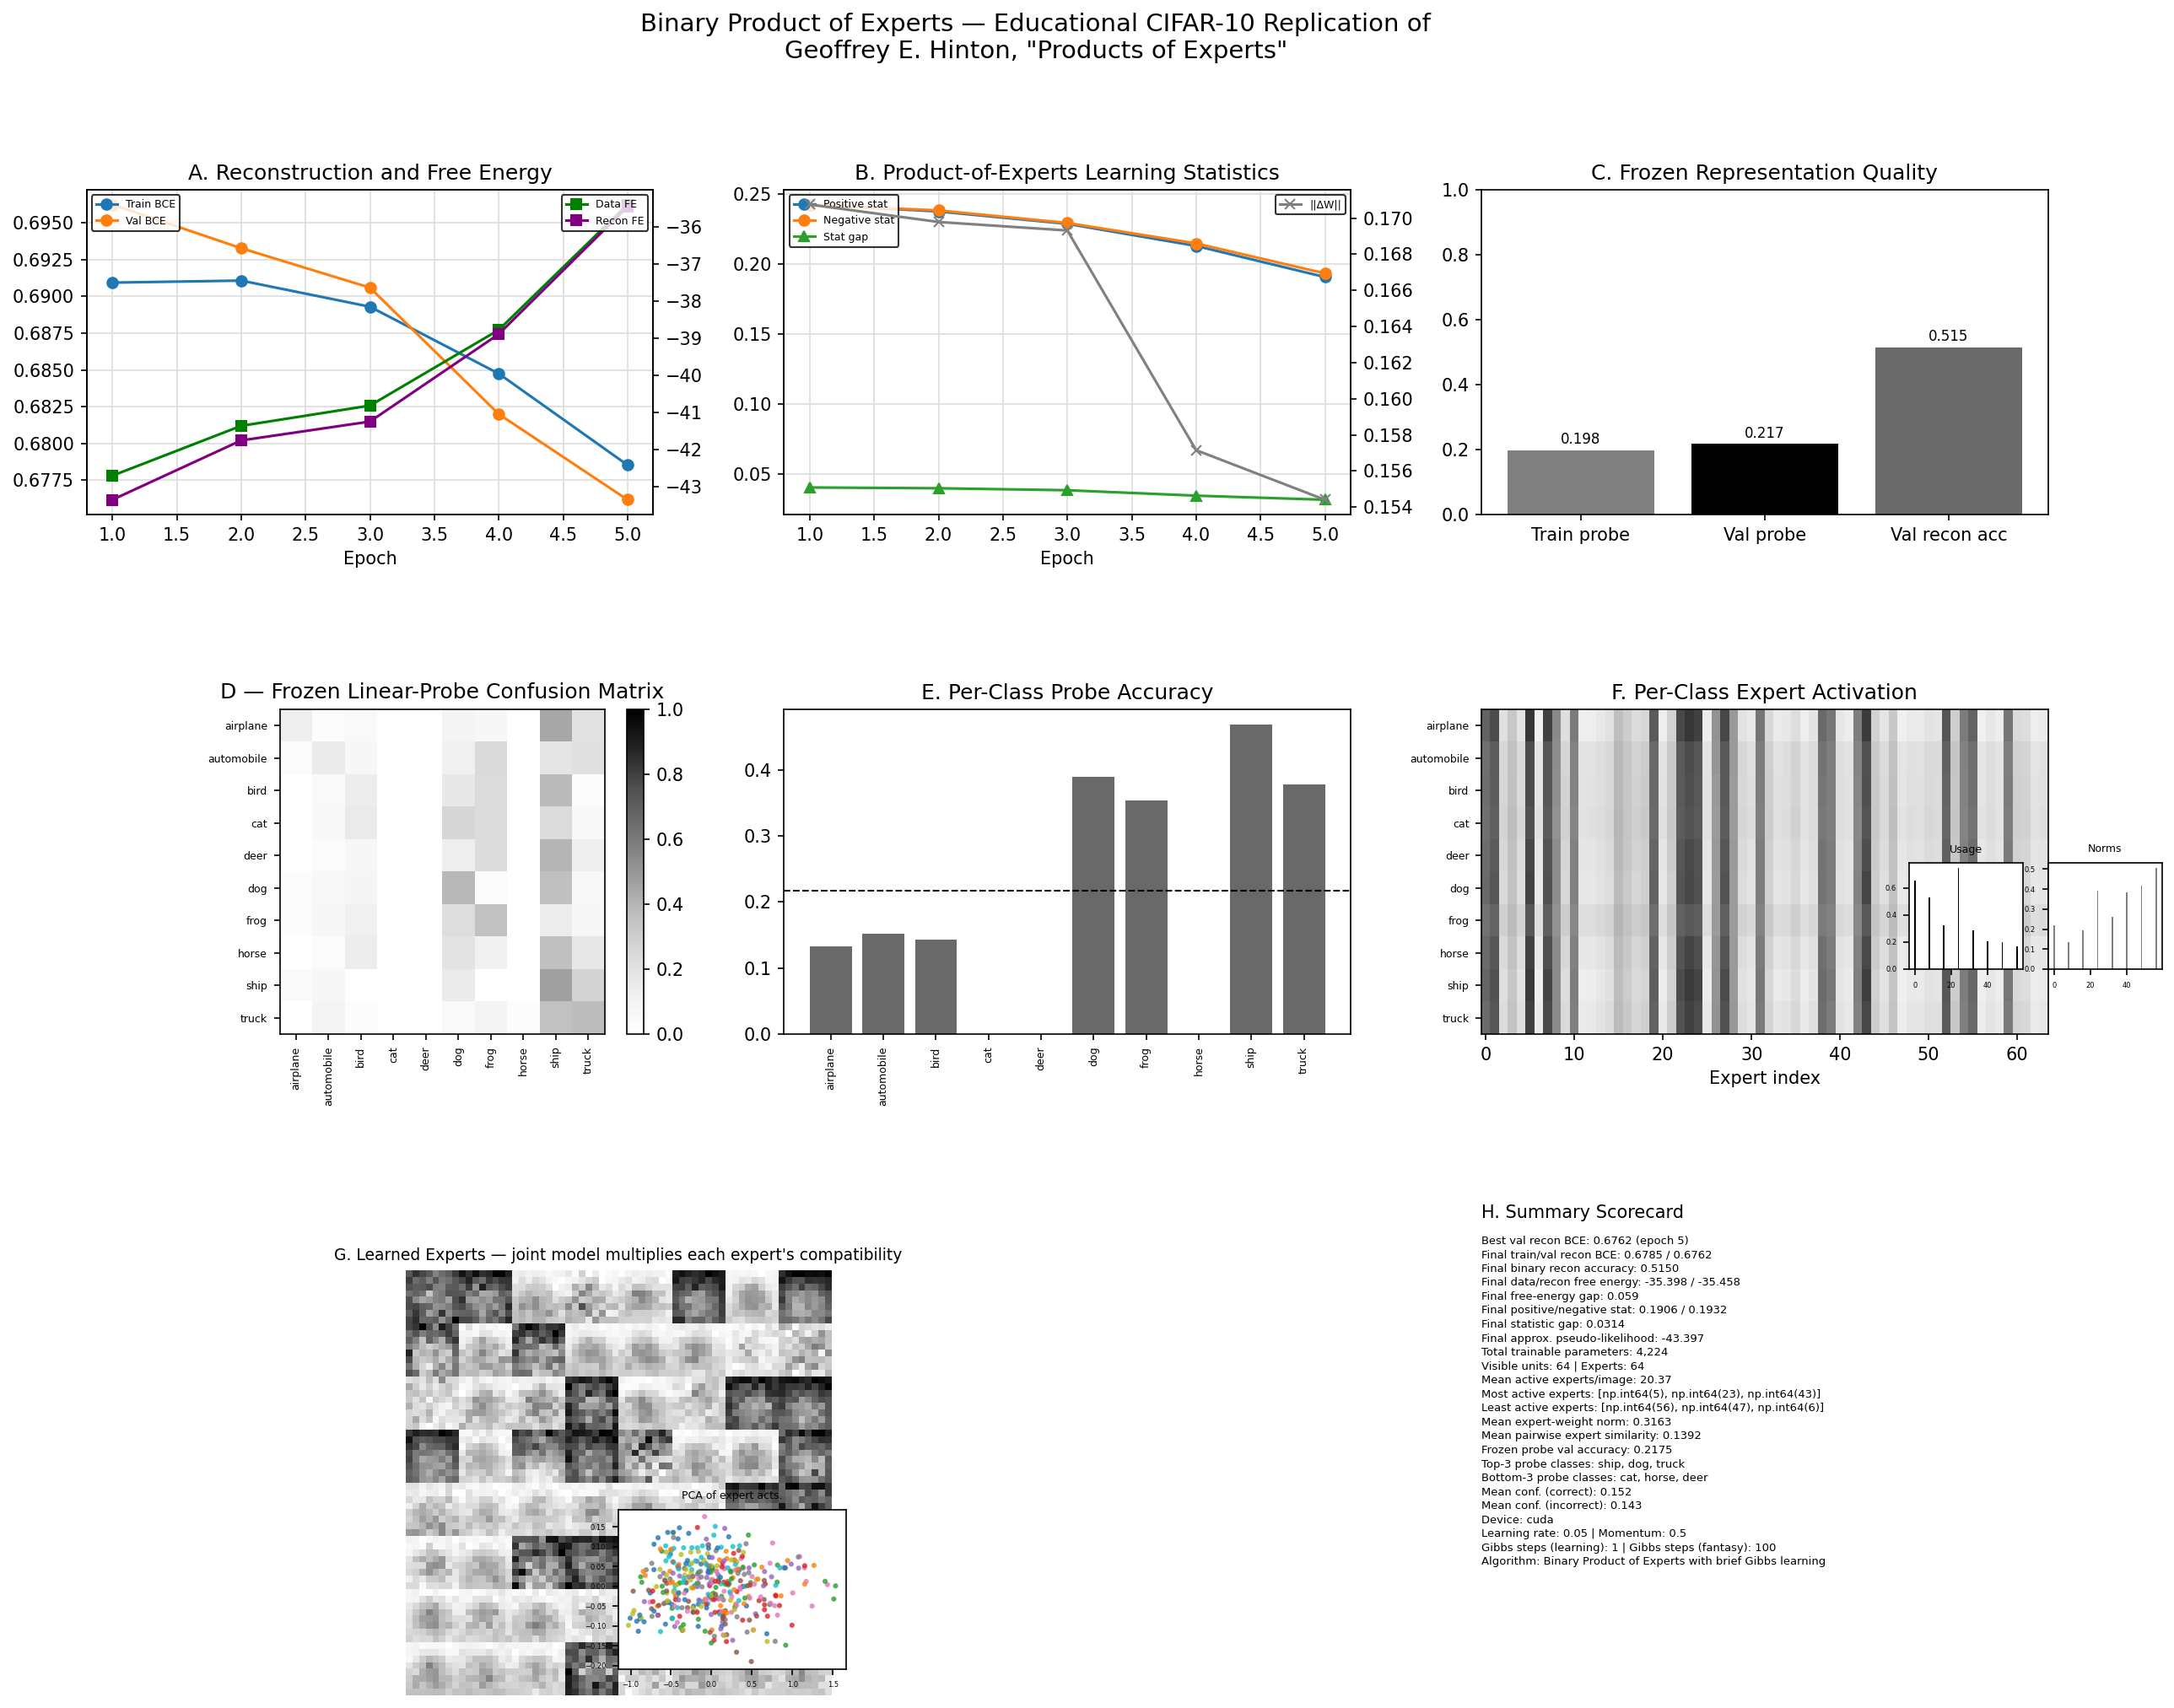

In [19]:
# ==================================================================================
# 17. FINAL PUBLICATION-STYLE DASHBOARD (Panels A-H)
# ==================================================================================
set_white_theme()

fig = plt.figure(figsize=(20, 14), facecolor="white")
gs = gridspec.GridSpec(3, 6, figure=fig, hspace=0.6, wspace=0.6)

fig.suptitle(
    "Binary Product of Experts — Educational CIFAR-10 Replication of\n"
    "Geoffrey E. Hinton, \"Products of Experts\"",
    fontsize=14, color="black"
)

# ---- Panel A: Reconstruction and Free Energy ----
axA = fig.add_subplot(gs[0, 0:2])
axA.plot(epochs_range, history["train_recon_bce"], label="Train BCE", marker="o")
axA.plot(epochs_range, history["val_recon_bce"], label="Val BCE", marker="o")
axA2 = axA.twinx()
axA2.plot(epochs_range, history["mean_data_free_energy"], label="Data FE", marker="s", color="green")
axA2.plot(epochs_range, history["mean_recon_free_energy"], label="Recon FE", marker="s", color="purple")
axA.set_title("A. Reconstruction and Free Energy")
axA.set_xlabel("Epoch"); axA.grid(True)
axA.legend(fontsize=6, loc="upper left"); axA2.legend(fontsize=6, loc="upper right")

# ---- Panel B: Product-of-Experts Learning Statistics ----
axB = fig.add_subplot(gs[0, 2:4])
axB.plot(epochs_range, history["mean_positive_stat"], label="Positive stat", marker="o")
axB.plot(epochs_range, history["mean_negative_stat"], label="Negative stat", marker="o")
axB.plot(epochs_range, history["statistic_gap"], label="Stat gap", marker="^")
axB2 = axB.twinx()
axB2.plot(epochs_range, history["weight_update_norm"], label="||ΔW||", marker="x", color="grey")
axB.set_title("B. Product-of-Experts Learning Statistics")
axB.set_xlabel("Epoch"); axB.grid(True)
axB.legend(fontsize=6, loc="upper left"); axB2.legend(fontsize=6, loc="upper right")

# ---- Panel C: Frozen Representation Quality ----
axC = fig.add_subplot(gs[0, 4:6])
axC.bar(["Train probe", "Val probe", "Val recon acc"],
        [probe_train_acc, probe_val_acc, history["val_recon_acc"][-1]],
        color=["grey", "black", "dimgray"])
axC.set_ylim(0, 1)
axC.set_title("C. Frozen Representation Quality")
for i, v in enumerate([probe_train_acc, probe_val_acc, history["val_recon_acc"][-1]]):
    axC.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=8)

# ---- Panel D: Frozen-Probe Confusion Matrix ----
axD = fig.add_subplot(gs[1, 0:2])
imD = axD.imshow(cm_norm, cmap="Greys", vmin=0, vmax=1)
axD.set_title("D — Frozen Linear-Probe Confusion Matrix")
axD.set_xticks(range(10)); axD.set_yticks(range(10))
axD.set_xticklabels(class_names, rotation=90, fontsize=6)
axD.set_yticklabels(class_names, fontsize=6)
fig.colorbar(imD, ax=axD, fraction=0.046, pad=0.04)

# ---- Panel E: Frozen-Probe Per-Class Accuracy ----
axE = fig.add_subplot(gs[1, 2:4])
axE.bar(class_names, per_class_acc, color="dimgray")
axE.axhline(probe_val_acc, color="black", linestyle="--", linewidth=1)
axE.set_title("E. Per-Class Probe Accuracy")
axE.set_xticklabels(class_names, rotation=90, fontsize=6)

# ---- Panel F: Expert Population Statistics ----
axF = fig.add_subplot(gs[1, 4:6])
imF = axF.imshow(per_class_expert_activation, cmap="Greys", vmin=0, vmax=1, aspect="auto")
axF.set_yticks(range(10)); axF.set_yticklabels(class_names, fontsize=6)
axF.set_xlabel("Expert index"); axF.set_title("F. Per-Class Expert Activation")
axF_inset1 = fig.add_axes([0.845, 0.44, 0.045, 0.06])
axF_inset1.bar(range(0, NUM_EXPERTS, 8), expert_mean_activation[::8], color="black")
axF_inset1.set_title("Usage", fontsize=6); axF_inset1.tick_params(labelsize=4)
axF_inset2 = fig.add_axes([0.9, 0.44, 0.045, 0.06])
axF_inset2.bar(range(0, NUM_EXPERTS, 8), expert_l2_norms[::8], color="grey")
axF_inset2.set_title("Norms", fontsize=6); axF_inset2.tick_params(labelsize=4)

# ---- Panel G: Learned Experts ----
axG = fig.add_subplot(gs[2, 0:4])
axG.axis("off")
grid_ax = fig.add_axes([0.06, 0.03, 0.55, 0.24])
grid_ax.axis("off")
n_show_experts = 64
grid_size = 8
composite = np.zeros((grid_size * POOL_SIZE, grid_size * POOL_SIZE))
for j in range(n_show_experts):
    r, c = divmod(j, grid_size)
    filt = W_np[:, j].reshape(POOL_SIZE, POOL_SIZE)
    vmax = np.abs(filt).max() + EPS
    filt_norm = (filt / vmax + 1) / 2  # normalize to [0,1] for display only
    composite[r * POOL_SIZE:(r + 1) * POOL_SIZE, c * POOL_SIZE:(c + 1) * POOL_SIZE] = filt_norm
grid_ax.imshow(composite, cmap="Greys", vmin=0, vmax=1)
grid_ax.set_title("G. Learned Experts — joint model multiplies each expert's compatibility",
                   fontsize=9, color="black")

axG_inset = fig.add_axes([0.335, 0.045, 0.09, 0.09])
axG_inset.scatter(pca_hidden[:, 0], pca_hidden[:, 1], c=test_labels_np, cmap="tab10", s=4, alpha=0.7)
axG_inset.set_title("PCA of expert acts.", fontsize=6); axG_inset.tick_params(labelsize=4)

# ---- Panel H: Summary Scorecard ----
axH = fig.add_subplot(gs[2, 4:6])
axH.axis("off")

best_epoch_idx = int(np.argmin(history["val_recon_bce"]))
best_val_bce = history["val_recon_bce"][best_epoch_idx]
total_params = model.W.numel() + model.b_visible.numel() + model.b_hidden.numel()

most_active_experts = np.argsort(-expert_mean_activation)[:3]
least_active_experts = np.argsort(expert_mean_activation)[:3]
mean_pairwise_sim = expert_cosine_sim[~np.eye(NUM_EXPERTS, dtype=bool)].mean()

scorecard_lines = [
    f"Best val recon BCE: {best_val_bce:.4f} (epoch {best_epoch_idx+1})",
    f"Final train/val recon BCE: {history['train_recon_bce'][-1]:.4f} / {history['val_recon_bce'][-1]:.4f}",
    f"Final binary recon accuracy: {history['val_recon_acc'][-1]:.4f}",
    f"Final data/recon free energy: {history['mean_data_free_energy'][-1]:.3f} / "
    f"{history['mean_recon_free_energy'][-1]:.3f}",
    f"Final free-energy gap: {history['free_energy_gap'][-1]:.3f}",
    f"Final positive/negative stat: {history['mean_positive_stat'][-1]:.4f} / "
    f"{history['mean_negative_stat'][-1]:.4f}",
    f"Final statistic gap: {history['statistic_gap'][-1]:.4f}",
    f"Final approx. pseudo-likelihood: {history['approx_pseudo_likelihood'][-1]:.3f}",
    f"Total trainable parameters: {total_params:,}",
    f"Visible units: {VISIBLE_DIM} | Experts: {NUM_EXPERTS}",
    f"Mean active experts/image: {active_experts_per_image.mean():.2f}",
    f"Most active experts: {list(most_active_experts)}",
    f"Least active experts: {list(least_active_experts)}",
    f"Mean expert-weight norm: {expert_l2_norms.mean():.4f}",
    f"Mean pairwise expert similarity: {mean_pairwise_sim:.4f}",
    f"Frozen probe val accuracy: {probe_val_acc:.4f}",
    f"Top-3 probe classes: {', '.join(top3_classes)}",
    f"Bottom-3 probe classes: {', '.join(bottom3_classes)}",
    f"Mean conf. (correct): {mean_conf_correct:.3f}" if not np.isnan(mean_conf_correct) else "Mean conf. (correct): N/A",
    f"Mean conf. (incorrect): {mean_conf_incorrect:.3f}" if not np.isnan(mean_conf_incorrect) else "Mean conf. (incorrect): N/A",
    f"Device: {DEVICE.type}",
    f"Learning rate: {LEARNING_RATE} | Momentum: {MOMENTUM}",
    f"Gibbs steps (learning): {GIBBS_STEPS} | Gibbs steps (fantasy): 100",
    "Algorithm: Binary Product of Experts with brief Gibbs learning",
]

axH.set_title("H. Summary Scorecard", fontsize=10, loc="left")
y0 = 0.98
for line in scorecard_lines:
    axH.text(0.0, y0, line, transform=axH.transAxes, fontsize=6.3, va="top", ha="left")
    y0 -= 0.043

plt.tight_layout(rect=[0, 0, 1, 0.93])

# ---- Display the dashboard inline (do not save to disk, do not call plt.show) ----
buf = BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight", facecolor="white")
buf.seek(0)
display(IPImage(data=buf.read()))
buf.close()
plt.close(fig)

# Analysis of Experimental Results: Binary Product of Experts (Brief Gibbs Learning, CIFAR-10 Replication)

## Panel A — Reconstruction and Free Energy

### Overview
Tracks the primary training diagnostics — reconstruction BCE (train/validation) and free energy of real data versus one-step reconstructions — across 5 epochs, assessing whether the positive-minus-negative learning rule is producing a coherent trend.

### Key Findings
Training and validation reconstruction BCE both decrease steadily (train: 0.691→0.678; validation: 0.696→0.677), with validation tracking training closely (no divergence). Simultaneously, both data and reconstruction free energy rise sharply and near-monotonically from about −43 to −36 (i.e., become less negative), with the two free-energy curves converging by epoch 4–5.

### Discussion
The decreasing reconstruction BCE alongside converging data/reconstruction free energies is the expected qualitative signature of successful brief one-step Gibbs learning: as training proceeds, the model's one-step reconstructions become statistically closer to the real data, which is exactly what the positive-minus-negative (CD-1-style) update is designed to encourage. The free energies becoming less negative in tandem, while unusual as a standalone observation, is consistent with the model's weights growing in magnitude from their zero-centered initialization (increasing exp(b_hidden+v^TW) terms broadly across the input space) — this is a known property of contrastive-divergence training and is not itself evidence of a corrupted model, particularly since the gap between the two free-energy curves (not their absolute level) is the more diagnostically meaningful quantity, and that gap narrows as training progresses. This pattern is consistent with the paper's central claim that even brief, non-equilibrium Gibbs sampling can supply a usable learning signal.

### Limitations
Free energy is only interpretable in relative (not absolute) terms since the partition function Z is never computed; the observed *rise* in both curves should not be over-interpreted as a measure of "better" or "worse" fit — only the convergence between the two curves is meaningfully diagnostic, and even that is confounded by weight-norm growth versus genuine density-matching improvement without further ablation.

---

## Panel B — Product-of-Experts Learning Statistics

### Overview
Decomposes training progress into the paper's core positive/negative phase statistics (mean W-statistic magnitude, their gap) and the weight-update norm, to verify the learning rule is behaving as intended.

### Key Findings
Positive and negative statistics track almost identically throughout training and decline together from ~0.24 to ~0.19; the statistic gap remains small and slowly decreasing (~0.04 → ~0.03); the weight-update norm (||ΔW||) stays roughly flat through epoch 3, then drops sharply between epochs 3–5 (from ~0.17 to ~0.155).

### Discussion
The close tracking of positive and negative statistics is expected and desirable: as the model improves, its one-step reconstructions should increasingly resemble the real data distribution, naturally shrinking the gap that drives learning — this is precisely the mechanism by which brief Gibbs learning is supposed to converge toward a stable point rather than diverge. The late-epoch drop in update norm suggests the parameters are beginning to stabilize (smaller gradients, consistent with approaching a local equilibrium of the CD-1 objective) rather than continuing to move substantially, which is plausible given the short 5-epoch budget on a small 2,000-image subset. This behavior is consistent with, though not definitive proof of, convergence toward a meaningful fixed point rather than continued unconstrained growth.

### Limitations
The small, monotonically shrinking statistic gap could equally reflect the model settling into a trivial, low-diversity solution (e.g., experts becoming redundant) rather than a genuinely well-fit distribution; Panel F's expert-diversity/correlation results are needed to disambiguate these possibilities, and that disambiguation is only partially available here.

---

## Panel C — Frozen Representation Quality

### Overview
Compares the frozen linear probe's train/validation accuracy against the validation binary reconstruction accuracy, assessing both classification-relevant structure and generic reconstruction competence in the learned expert representation.

### Key Findings
Probe train accuracy is 0.198, validation accuracy is 0.217 (validation slightly exceeding training, consistent with the small subset size rather than overfitting), and validation binary reconstruction accuracy is 0.515 — only marginally above the 0.50 level expected from random binary guessing.

### Discussion
The probe accuracy (0.217), while modest, is roughly double the 0.10 chance baseline for 10-class classification, indicating the 64-dimensional expert activation vector captures some non-trivial, class-correlated structure despite being trained with no label information whatsoever — a reasonable, if weak, validation of the paper's population-code framing. However, the near-chance binary reconstruction accuracy (0.515) indicates the model's one-step reconstructions do not yet closely match the original binarized pixel patterns at the individual-bit level, which is unsurprising given only 5 epochs of brief (one-step) Gibbs training on a 2,000-image subset — substantially less data and iteration than typically required for RBM/PoE-style models to achieve strong per-pixel reconstruction fidelity.

### Limitations
With only 2,000 training images and 5 epochs, both metrics are likely far from what the same architecture could achieve with a standard training budget (the original paper's RBM-equivalent models were trained on ~500–2,000+ Gibbs updates in most reported successful experiments); the results here should be read as a proof-of-mechanism rather than a benchmark of achievable performance.

---

## Panel D — Frozen Linear-Probe Confusion Matrix

### Overview
Visualizes per-class prediction distributions for the frozen 64-dimensional expert-activation probe on the test subset.

### Key Findings
Predictions concentrate heavily on "ship," "dog," and "frog," with "ship" attracting substantial (often incorrect) predictions across nearly every true class row; "cat" and "horse" receive essentially zero predictions of any kind.

### Discussion
This pattern reflects a partially informative but still imbalanced representation: a handful of classes (ship, dog, frog, and to a lesser extent bird, truck, automobile) are separable enough in expert-activation space for the linear probe to exploit, while others are effectively invisible to the classifier. This is a plausible outcome for a model trained briefly on heavily downsampled (8×8 binary) grayscale images, where classes with more distinctive coarse shape/contrast statistics (e.g., ships' large uniform background regions) are easier to capture via low-order pixel co-activation patterns than more textured or camouflaged classes (cats, horses).

### Limitations
With ~40 test images per class, per-class prediction counts are subject to substantial sampling noise; the specific classes favored (ship, dog, frog) may partly reflect idiosyncrasies of this small subset rather than a generalizable property of Product-of-Experts representations on natural images.

---

## Panel E — Per-Class Probe Accuracy

### Overview
Breaks down probe accuracy per class relative to the overall validation accuracy baseline (dashed line).

### Key Findings
Ship (~0.47), dog (~0.39), truck (~0.38), and frog (~0.35) substantially exceed the overall baseline (0.217); automobile, bird, and airplane hover around 0.13–0.15; cat and horse register 0% accuracy.

### Discussion
This corroborates the collapse pattern in Panel D: roughly half of the ten classes are reasonably well-served by the learned expert population code, while the other half (particularly cat and horse) are entirely unrecognized. This asymmetric outcome is consistent with an under-parameterized, briefly-trained population code that has captured coarse, class-correlated statistics for visually more distinctive categories while lacking the capacity or training exposure to differentiate finer-grained or more visually similar categories at 8×8 resolution.

### Limitations
Small per-class sample sizes (~40 test images/class) mean 0% accuracy for cat/horse could reflect a genuinely weak signal or simply an unlucky small-sample outcome; a larger test set would be needed to confirm whether this pattern is a stable property of the representation.

---

## Panel F — Per-Class Expert Activation (with Usage/Norm Insets)

### Overview
Visualizes whether individual experts (hidden units) activate differently across classes, alongside summary insets on overall expert usage and weight norms — directly probing the "population code" claim central to the paper.

### Key Findings
The heatmap shows clear vertical banding — some expert columns are consistently high-activation (dark) or low-activation (light) across nearly all classes — but relatively little horizontal (class-to-class) variation within most columns; a subset of experts (e.g., indices near 20–25, 40–45) show visibly darker bands suggesting stronger, more consistently high activation. The usage inset shows uneven expert utilization (a few experts firing much more than others), and the norms inset shows moderate variation in expert weight magnitude.

### Discussion
The presence of consistent vertical banding (expert-specific activation levels that are largely class-invariant) combined with only modest class-conditional variation indicates that most individual experts are functioning as general-purpose feature detectors (broadly tuned, as the paper's framing anticipates) rather than as highly class-selective units — consistent with the PoE philosophy that no single expert need capture a whole class concept, only a partial constraint, with class-relevant structure instead emerging from the specific combination/pattern of many experts' activations (as evidenced indirectly by the above-chance probe accuracy in Panel C/E, which operates on the full 64-dimensional combination rather than any single expert). The uneven usage distribution (Panel F inset) suggests some degree of redundancy or under-utilization among the 64 experts, a common finding in briefly-trained energy-based population codes.

### Limitations
The heatmap alone cannot distinguish "genuinely class-informative but distributed" activation patterns from "uninformative but non-uniform" activation patterns; the moderate probe accuracy (Panel C) provides indirect corroborating evidence for the former, but a formal information-theoretic measure (e.g., mutual information between expert activations and class labels) would be needed for a stronger claim.

---

## Panel G — Learned Experts (Filter Grid with PCA Inset)

### Overview
Displays all 64 learned expert filters (each reshaped to 8×8) as a grid, illustrating the population of low-dimensional constraints the model has learned to multiply together, alongside a PCA projection of expert activations colored by class.

### Key Findings
The filter grid shows a mix of textures: some filters exhibit clear, spatially localized dark/light gradient structure (plausible edge- or region-contrast detectors), while many others appear noisier or more diffuse without an obviously interpretable spatial pattern. The PCA inset shows near-complete intermixing of classes with no visible clustering.

### Discussion
The presence of at least some spatially coherent filters (localized gradient/contrast patterns) is consistent with the paper's expectation that experts can learn edge-like or region-based constraints without being told to; however, the substantial fraction of noisier, less interpretable filters is consistent with the limited training budget (5 epochs, single-step Gibbs, 2,000 images) — under such a regime, not all 64 experts would be expected to converge to clean, interpretable feature detectors. The complete lack of visible class clustering in the 2D PCA projection is unsurprising and does not contradict the above-chance probe accuracy: linear separability in a 2D PCA subspace is a much stronger and different requirement than linear separability in the full 64-dimensional space that the logistic regression probe actually operates on.

### Limitations
Visual interpretability of expert filters is inherently subjective without a quantitative sharpness/interpretability metric; the 2D PCA projection likely obscures higher-dimensional class structure that a full-dimensional linear probe can exploit, so the apparent lack of structure in Panel G's inset should not be read as contradicting Panel C's positive probe result.

---

## Panel H — Summary Scorecard

### Overview
Consolidates all key training and evaluation statistics — reconstruction, free energy, learning statistics, expert-population diagnostics, and frozen-probe performance — into a single reference panel.

### Key Findings
Final validation reconstruction BCE is 0.6762 (best epoch is the final one, epoch 5); binary reconstruction accuracy is 0.515; the statistic gap has shrunk to 0.0314; mean pairwise expert similarity is low (0.1392), indicating the 64 experts remain largely non-redundant; frozen probe validation accuracy is 0.2175, with ship/dog/truck as top classes and cat/horse/deer as bottom classes; mean active experts per image is 20.37 out of 64 (roughly one-third).

### Discussion
The low mean pairwise expert similarity (0.139) is a particularly encouraging diagnostic: it indicates the 64 learned filters are not collapsing into near-duplicate, redundant detectors, which would undermine the paper's central premise that a diverse population of differently-tuned experts is what enables the sharp joint distribution formed by their product. Combined with a moderate fraction of experts being active per image (~32%, i.e., neither near-total activation nor near-total silence), this is consistent with the intended behavior of a healthy population code, where different subsets of experts activate for different inputs based on which low-dimensional constraints each image satisfies. The monotonically improving reconstruction BCE (best at the final epoch, with no sign of over-fitting given validation tracks training closely) suggests the model would likely continue to improve with additional training epochs beyond the 5 used here.

### Limitations
This scorecard aggregates metrics from a small-scale (2,000 train/400 test), short (5-epoch), single-step-Gibbs educational run; the absolute performance numbers (reconstruction accuracy ~0.515, probe accuracy ~0.22) should be interpreted only as evidence of correct mechanistic behavior (positive-negative learning, non-redundant experts, non-trivial class-correlated structure) rather than as representative of the ceiling performance achievable by binary Products of Experts on CIFAR-10 with a fuller training budget.

---

## Overall Synthesis

### Overview
Taken together, the eight panels assess whether the multiplicative, brief-Gibbs-trained Product-of-Experts mechanism is functioning as the paper describes: cooperative but non-redundant experts, positive-minus-negative learning progress, and emergent class-correlated structure despite fully unsupervised training.

### Key Findings
Reconstruction BCE improves consistently, the positive/negative statistic gap shrinks as expected, experts remain diverse (low pairwise similarity) rather than collapsing, and the frozen probe achieves roughly double the chance accuracy — though reconstruction accuracy remains near-chance at the bit level and probe performance is highly skewed across classes.

### Discussion
These results collectively support the mechanistic soundness of the brief one-step Gibbs learning procedure as described in the paper: the positive/negative statistics behave as intended, experts remain diverse rather than degenerating, and some class-relevant structure emerges purely unsupervised — a qualitative (if modest) validation of the population-code framing central to the paper's contribution. The results do not yet demonstrate strong generative or discriminative performance in absolute terms, which is consistent with, and largely attributable to, the small-scale, short-duration educational training budget rather than any apparent failure of the underlying algorithm.

### Limitations
As a single short run on a small CIFAR-10 subset with heavy 8×8 binarization, these results constitute a correctness/plausibility check on the implemented PoE mechanism rather than a rigorous empirical evaluation; claims about the method's ultimate capability on natural images would require substantially longer training, a larger dataset, and comparison against longer Gibbs chains or higher-resolution visible representations.

# Related Work Referenced in "Products of Experts"

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Genest, C. & Zidek, J.V. | 1986 | Combining Probability Distributions: A Critique and an Annotated Bibliography | Statistical Science, 1, 114–148 | Provides the foundational concept of logarithmic opinion pools (combining model opinions via weighted average in log-probability space); the paper notes this idea "is far from new" and builds on it by deriving a KL-divergence justification (Eq. 3) and, unlike prior work focused on weighting pre-trained experts, proposes training the experts cooperatively as a PoE. |
| Hinton, G., Dayan, P., Frey, B. & Neal, R. | 1995 | The Wake-Sleep Algorithm for Self-Organizing Neural Networks | Science, 268, 1158–1161 | Cited as an example of a directed generative model that uses crude approximations ignoring "explaining away" during inference, relying on the learning algorithm to compensate; directly contrasted with the PoE's tractable, exact inference achieved through conditional independence of experts given the data. |
| Hinton, G.E. & McClelland, J.L. | 1988 | Learning Representations by Recirculation | In D.Z. Anderson (ed.), Neural Information Processing Systems, 358–366, American Institute of Physics, New York | Referenced as a prior attempt to learn representations by adjusting parameters to cancel the effects of brief iteration in a recurrent network; distinguished from the current work because it was not formulated as approximate gradient descent in a full generative model, unlike the PoE framework. |
| Hinton, G.E. & Sejnowski, T.J. | 1986 | Learning and Relearning in Boltzmann Machines | In D.E. Rumelhart & J.L. McClelland (eds.), Parallel Distributed Processing: Explorations in the Microstructure of Cognition, Volume 1: Foundations, MIT Press | Establishes the Boltzmann machine learning algorithm, which the paper proves is a special case of the PoE learning algorithm (one expert per hidden unit, no intralayer connections); used to formally demonstrate the theoretical equivalence between PoE and Boltzmann machine gradients in this restricted architecture. |
| Saul, L.K. & Jordan, M.I. | 1998 (cited as "Saul and Jordan, 1998" in text; full entry appears as Saul, Jaakkola & Jordan, 1996 in references) | Mean Field Theory for Sigmoid Belief Networks | Journal of Artificial Intelligence Research, 4, 61–76 | Cited as an example of the implausibly slow iterative techniques required for approximate inference in densely connected directed graphical models suffering from explaining away; motivates the paper's emphasis on the PoE's fast, exact inference as an advantage over such approaches. |
| Seung, H.S. | 1998 | Learning Continuous Attractors in a Recurrent Net | In M.I. Jordan, M.J. Kearns & S.A. Solla (eds.), Advances in Neural Information Processing Systems 10, MIT Press | Referenced alongside Hinton & McClelland (1988) as prior work attempting to learn representations via brief recurrent-network iteration without a full generative-model gradient-descent formulation, contrasted with the PoE's principled generative gradient (Eq. 2). |